In [22]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/home/tjdu/micromamba/envs/solar-forecasting-hk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
import os
import torch

def check_and_prepare_resume(
    ckpt_path,
    model,
    optimizer=None,
    total_epochs=None,
    train_loader=None,
    device="cpu",
    verbose=True,
):
    """
    Check checkpoint status and prepare safe resume information.

    Returns a dict:
      {
        can_resume: bool,
        start_epoch: int or None,
        load_model: bool,
        load_optimizer: bool,
        reason: str,
        warnings: list[str]
      }
    """

    info = {
        "ckpt_path": ckpt_path,
        "exists": False,
        "can_resume": False,
        "start_epoch": None,
        "load_model": False,
        "load_optimizer": False,
        "warnings": [],
        "reason": "",
    }

    if not os.path.isfile(ckpt_path):
        info["reason"] = "Checkpoint file does not exist."
        return info

    info["exists"] = True
    ckpt = torch.load(ckpt_path, map_location=device)

    # -------------------------
    # Case 1: model-only pt
    # -------------------------
    if not isinstance(ckpt, dict):
        try:
            missing, unexpected = model.load_state_dict(ckpt, strict=False)
            if missing or unexpected:
                info["warnings"].append(
                    f"Model-only checkpoint has mismatched keys "
                    f"(missing={len(missing)}, unexpected={len(unexpected)})"
                )
            info["can_resume"] = True
            info["load_model"] = True
            info["reason"] = "Model-only checkpoint (optimizer/scheduler will reset)."
            return info
        except Exception as e:
            info["reason"] = f"Failed to load model-only checkpoint: {e}"
            return info

    # -------------------------
    # Dict-style checkpoint
    # -------------------------
    keys = set(ckpt.keys())

    if "model" not in keys:
        info["reason"] = "Checkpoint dict has no model state."
        return info

    # ---- model load test ----
    try:
        missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
        if missing or unexpected:
            info["warnings"].append(
                f"Model key mismatch: missing={len(missing)}, unexpected={len(unexpected)}"
            )
        info["load_model"] = True
    except Exception as e:
        info["reason"] = f"Model weights incompatible: {e}"
        return info

    # ---- epoch ----
    if "epoch" not in keys:
        info["warnings"].append("No epoch stored in checkpoint.")
    else:
        start_epoch = int(ckpt["epoch"]) + 1
        info["start_epoch"] = start_epoch

    # ---- optimizer ----
    if optimizer is not None and "optimizer" in keys:
        try:
            optimizer.load_state_dict(ckpt["optimizer"])
            info["load_optimizer"] = True
        except Exception as e:
            info["warnings"].append(f"Optimizer state incompatible: {e}")
    else:
        info["warnings"].append("No optimizer state in checkpoint.")

    # ---- OneCycle sanity check ----
    if (
        total_epochs is not None
        and train_loader is not None
        and info["start_epoch"] is not None
    ):
        steps_per_epoch = len(train_loader)
        total_steps = total_epochs * steps_per_epoch
        steps_done = info["start_epoch"] * steps_per_epoch

        if steps_done >= total_steps:
            info["warnings"].append(
                f"Checkpoint already beyond OneCycle total_steps "
                f"({steps_done} >= {total_steps})."
            )

    # ---- final decision ----
    info["can_resume"] = info["load_model"]
    info["reason"] = "Checkpoint can be used to resume training."

    # -------------------------
    # Pretty print
    # -------------------------
    if verbose:
        print("=" * 80)
        print(f"Checkpoint path : {ckpt_path}")
        print(f"Exists          : {info['exists']}")
        print(f"Load model      : {info['load_model']}")
        print(f"Load optimizer  : {info['load_optimizer']}")
        print(f"Start epoch     : {info['start_epoch']}")
        print(f"Can resume      : {info['can_resume']}")
        if info["warnings"]:
            print("\nWARNINGS:")
            for w in info["warnings"]:
                print(" -", w)
        else:
            print("\nNo warnings.")
        print(f"\nReason: {info['reason']}")
        print("=" * 80)

    return info


In [24]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
    train_one_epoch_gate,
    evaluate_moe
)
from src.plot import(
    plot_full_images_from_loader,plot_rmse_extremes_with_time_and_ghi
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.utils import crop_back, pad_to_32
from src.model_Twin import(TwinFiLMUNetTiny_MoE)

In [ ]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_fuzzy_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [8]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_fuzzy.npz",
)

print("Saved:", out)
print("Final shape:", shape)


Saved: Data/output/combined_hourly_with_elev_landmask_fuzzy.npz
Final shape: (46277, 12, 50, 50)


In [25]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_fuzzy.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (46277, 12, 50, 50)
y shape: (46277, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


In [26]:
import numpy as np

def compute_means(arr):
    # arr: (T,H,W) or (T,1,H,W)
    if arr.ndim == 4:
        arr = arr[:, 0]
    return arr.mean(axis=(1,2))

def make_labels(c0, c1, csi,
                tw_cs_thr=76.0,      # W/m^2 : twilight if clear-sky GHI below this
                clear_thr=0.80,      # CSI mean threshold for "clear"
                cloudy_thr=0.35):    # CSI mean threshold for "cloudy"
    """
    Returns labels:
      0=twilight, 1=clear, 2=cloudy, 3=mixed
    """
    c0m  = compute_means(c0)
    c1m  = compute_means(c1)
    csim = compute_means(csi)

    labels = np.full(len(c1m), 3, dtype=np.int64)  # default mixed

    tw = c1m < tw_cs_thr
    labels[tw] = 0

    daytime = ~tw
    labels[daytime & (csim >= clear_thr)] = 1
    labels[daytime & (csim <= cloudy_thr)] = 2

    return labels, {"c0_mean": c0m, "c1_mean": c1m, "csi_mean": csim}


In [27]:
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_train_val_test_split(labels, train=0.7, val=0.15, test=0.15, seed=42):
    idx = np.arange(len(labels))

    idx_train, idx_tmp, y_train, y_tmp = train_test_split(
        idx, labels, test_size=(1-train), random_state=seed, stratify=labels
    )

    val_frac_of_tmp = val / (val + test)
    idx_val, idx_test, _, _ = train_test_split(
        idx_tmp, y_tmp, test_size=(1-val_frac_of_tmp),
        random_state=seed, stratify=y_tmp
    )
    return idx_train, idx_val, idx_test


In [9]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)

In [30]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_train_val_test_split(labels, 0.8, 0.1, 0.1, seed=42)

In [31]:
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [32]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_strat_stats_day_30mins_no_twillight_fuzzy.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)

channel_min: [187.04999 183.7     185.03    182.54    208.81999 182.60999 181.82
 182.57999 185.31999  38.89      0.        0.     ]
channel_max: [258.57     268.59     272.86     307.13     279.04     311.44998
 310.09     302.99     281.24      40.579998 804.1716     1.      ]


In [33]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [34]:
import kornia
import torch.nn as nn
import torch.nn.functional as F
criterion_reg  = nn.SmoothL1Loss(beta=0.03)  # sharper than 0.05
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")


def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).reshape(1,1,3,3)
    lp = torch.nn.functional.conv2d(pred, k, padding=1)
    lt = torch.nn.functional.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

# def combined_loss(y_pred, y_true, w_reg=0.7, w_ssim=0.1, w_grad=0.15, w_lap=0.05):
#     return (
#         w_reg * criterion_reg(y_pred, y_true)
#         + w_ssim * criterion_ssim(y_pred, y_true)
#         + w_grad * grad_loss(y_pred, y_true)
#         + w_lap * lap_loss(y_pred, y_true)
#     )

def combined_loss_mid_focus(y_pred, y_true,
                            w_mse=0.6, w_reg=0.3, w_grad=0.1,
                            y_sat=0.98, mid_boost=3.0):
    # mask
    mid = (y_true < y_sat).float()
    w = 1.0 + mid_boost * mid     # mid像素權重=1+mid_boost, sat像素權重=1

    reg = (w * F.smooth_l1_loss(y_pred, y_true, beta=0.03, reduction="none")).mean()
    mse = (w * (y_pred - y_true).pow(2)).mean()
    g   = grad_loss(y_pred, y_true)

    return w_mse*mse + w_reg*reg + w_grad*g


In [ ]:
! export CUDA_VISIBLE_DEVICES=0 

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)

In [17]:
model = TwinFiLMUNetTiny_MoE(feature_size=48).to(device)

In [ ]:
# ...existing code...
import os, torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch.cuda.is_available:", torch.cuda.is_available())
print("visible GPU count:", torch.cuda.device_count())

# confirm model parameters device
print("model device:", next(model.parameters()).device)

# show per-GPU memory usage (should be nonzero on only one device)
for i in range(torch.cuda.device_count()):
    used = torch.cuda.memory_allocated(i) / 1024**2
    reserved = torch.cuda.memory_reserved(i) / 1024**2
    print(f"GPU {i}: allocated={used:.1f}MB reserved={reserved:.1f}MB")

# enforce single visible GPU
assert torch.cuda.device_count() == 1, f"Expected 1 visible GPU, got {torch.cuda.device_count()}"
# ...existing code...

In [18]:
import os
import torch

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.0, mode="min",
                 warmup_epochs=0, ckpt_path="best.pt", verbose=True):
        """
        mode: 'min' for val_loss / rmse (smaller is better)
              'max' for metrics like R2 (bigger is better)
        """
        assert mode in ("min", "max")
        self.patience = patience
        self.min_delta = float(min_delta)
        self.mode = mode
        self.warmup_epochs = int(warmup_epochs)
        self.ckpt_path = ckpt_path
        self.verbose = verbose

        self.best = None
        self.num_bad = 0
        self.best_epoch = -1

    def _is_improvement(self, current):
        if self.best is None:
            return True
        if self.mode == "min":
            return current < (self.best - self.min_delta)
        else:
            return current > (self.best + self.min_delta)

    def step(self, current_metric, epoch, model, optimizer=None, extra=None):
        """
        Returns: (should_stop: bool, saved_best: bool)
        """
        saved = False

        # Don't early stop during warmup, but still allow saving best
        improved = self._is_improvement(current_metric)
        if improved:
            self.best = float(current_metric)
            self.best_epoch = int(epoch)
            self.num_bad = 0
            saved = True

            payload = {"epoch": epoch,
                       "best_metric": self.best,
                       "model": model.state_dict()}
            if optimizer is not None:
                payload["optimizer"] = optimizer.state_dict()
            if extra is not None:
                payload["extra"] = extra

            # overwrite single file
            torch.save(payload, self.ckpt_path)
            if self.verbose:
                print(f"  [EarlyStopping] New best saved: {self.best:.6f} @ epoch {epoch+1} -> {self.ckpt_path}")
        else:
            if epoch >= self.warmup_epochs:
                self.num_bad += 1

        should_stop = (epoch >= self.warmup_epochs) and (self.num_bad >= self.patience)
        if should_stop and self.verbose:
            print(f"  [EarlyStopping] Stop: no improvement for {self.patience} epochs. "
                  f"Best={self.best:.6f} @ epoch {self.best_epoch+1}")

        return should_stop, saved


In [23]:
best_path = "Model_checkpoint/best_moe.pt"
early = EarlyStopping(
    patience=15,        # 你这数据量+OneCycle，20 很常用
    min_delta=1e-4,     # RMSE 至少进步 0.0001 才算进步（避免抖动）
    mode="min",
    warmup_epochs=60,   # 让 OneCycle 先走一段，不要太早停
    ckpt_path=best_path,
    verbose=True
)

In [24]:
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
resume_info = check_and_prepare_resume(
    ckpt_path="Model_checkpoint/best_moe.pt",
    model=model,
    optimizer=optimizer,
    total_epochs=150,
    train_loader=train_loader,
    device=device,
)


Checkpoint path : Model_checkpoint/best_moe.pt
Exists          : True
Load model      : True
Load optimizer  : True
Start epoch     : 87
Can resume      : True

No warnings.

Reason: Checkpoint can be used to resume training.


In [25]:
import torch
from torch.optim.lr_scheduler import OneCycleLR
total_epochs = 150
model = TwinFiLMUNetTiny_MoE(feature_size=48).to(device)
ckpt_path = "Model_checkpoint/best_moe.pt"  
ckpt = torch.load(ckpt_path, map_location=device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
model.load_state_dict(ckpt["model"])
optimizer.load_state_dict(ckpt["optimizer"])

start_epoch = ckpt["epoch"] + 1
print("Resuming from epoch:", start_epoch)

# ---- rebuild OneCycleLR aligned to steps already done ----
steps_per_epoch = len(train_loader)
total_steps = total_epochs * steps_per_epoch
steps_done = start_epoch * steps_per_epoch
steps_done = min(steps_done, total_steps - 1)  # clamp, avoid overflow

scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=steps_per_epoch,
    epochs=total_epochs,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=5.0,
    final_div_factor=50.0,
    last_epoch=steps_done - 1,
)

for epoch in range(start_epoch, total_epochs):
    train_loss = train_one_epoch_gate(model, train_loader, optimizer, combined_loss_mid_focus, device, scheduler)
    val_loss, rmse = evaluate_moe(model, val_loader, combined_loss_mid_focus, device)

    print(f"Epoch {epoch+1:03d}/{total_epochs}: loss={train_loss:.6f} | val {val_loss:.4f} | rmse {rmse:.4f} | lr {optimizer.param_groups[0]['lr']}")
    should_stop, _ = early.step(current_metric=rmse, epoch=epoch, model=model, optimizer=optimizer)

    if should_stop:
        break

print(f"Best checkpoint: {best_path}")

Resuming from epoch: 87
Epoch 088/150: loss=0.054727 | val 0.0891 | rmse 0.1020 | lr 0.00021921226244955594
  [EarlyStopping] New best saved: 0.102020 @ epoch 88 -> Model_checkpoint/best_moe.pt
Epoch 089/150: loss=0.054470 | val 0.0895 | rmse 0.1022 | lr 0.00021347430663761635
Epoch 090/150: loss=0.053950 | val 0.0903 | rmse 0.1025 | lr 0.00020775667165062612
Epoch 091/150: loss=0.053923 | val 0.0899 | rmse 0.1030 | lr 0.00020206245368879587
Epoch 092/150: loss=0.053424 | val 0.0895 | rmse 0.1025 | lr 0.0001963947362716042
Epoch 093/150: loss=0.053085 | val 0.0893 | rmse 0.1023 | lr 0.0001907565885680172
Epoch 094/150: loss=0.052645 | val 0.0902 | rmse 0.1028 | lr 0.00018515106373447914
Epoch 095/150: loss=0.052357 | val 0.0900 | rmse 0.1026 | lr 0.00017958119726157497
Epoch 096/150: loss=0.052124 | val 0.0895 | rmse 0.1027 | lr 0.0001740500053302583
Epoch 097/150: loss=0.051714 | val 0.0889 | rmse 0.1022 | lr 0.000168560483178536
Epoch 098/150: loss=0.051342 | val 0.0890 | rmse 0.1021

In [ ]:
# import torch
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.optim.lr_scheduler import OneCycleLR

# model = TwinFiLMUNetTiny_MoE(feature_size=48).to(device)

# # -----------------------------
# # Optimizer + scheduler
# # -----------------------------
# total_epochs = 150
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

# scheduler = OneCycleLR(
#     optimizer,
#     max_lr=5e-4,
#     steps_per_epoch=len(train_loader),
#     epochs=total_epochs,
#     pct_start=0.1,
#     anneal_strategy="cos",
#     div_factor=5.0,        # initial lr = max_lr/div_factor
#     final_div_factor=50.0  # final lr = initial_lr/final_div_factor
# )

# # -----------------------------
# # Training loop
# # -----------------------------


# for epoch in range(total_epochs):
#     # 可选：MoE gate warm-up（如果你启用了 model.force_g）
#     # if epoch < 5: model.force_g = 0.5
#     # else: model.force_g = None

#     train_loss = train_one_epoch_gate(model, train_loader, optimizer, combined_loss_mid_focus, device, scheduler)
#     val_loss, rmse = evaluate_moe(model, val_loader, combined_loss_mid_focus, device)

#     print(f"Epoch {epoch+1:03d}/{total_epochs}: loss={train_loss:.6f} | val {val_loss:.4f} | rmse {rmse:.4f} | lr {optimizer.param_groups[0]['lr']}")

#     # Early stop on RMSE
#     should_stop, _ = early.step(current_metric=rmse, epoch=epoch, model=model, optimizer=optimizer)

#     if should_stop:
#         break

# print(f"Best checkpoint: {best_path}")

Epoch 001/150: loss=0.431308 | val 0.4326 | rmse 0.3621 | lr 0.00025389217331803665
  [EarlyStopping] New best saved: 0.362079 @ epoch 1 -> Model_checkpoint/best_moe.pt
Epoch 002/150: loss=0.431308 | val 0.4326 | rmse 0.3621 | lr 0.000248097810950113


KeyboardInterrupt: 

In [19]:
b = next(iter(train_loader))
print(type(b))
if isinstance(b, (list, tuple)):
    print("len:", len(b), "types:", [type(x) for x in b])
elif isinstance(b, dict):
    print("keys:", b.keys())


<class 'list'>
len: 2 types: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [31]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.105814
rRMSE: 0.151389
R2: 0.884695
MBE: -0.002843
MAE: 0.067120
mean_true: 0.698951


In [ ]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

In [29]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)

ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

In [47]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.088884
CSI_rRMSE: 0.127168
CSI_R2: 0.918639
CSI_MBE: 0.002784
CSI_MAE: 0.053263
CSI_mean_true: 0.698951
GHI_RMSE: 12.489087
GHI_rRMSE: 0.122078
GHI_R2: 0.966307
GHI_MBE: 0.507098
GHI_MAE: 7.093352
GHI_mean_true: 102.304237


In [44]:
15.432117*4

61.728468

CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058

In [ ]:
# ckpt_path = "Model_checkpoint/ckpt_last2.pt"

# torch.save({
#     "epoch": epoch,                      # current epoch index (0-based)
#     "model": model.state_dict(),
#     "optimizer": optimizer.state_dict(),
#     "scheduler": scheduler.state_dict() if scheduler is not None else None,
# }, ckpt_path)


In [10]:
PATH = "Model_checkpoint/best_moe.pt" #"Model_checkpoint/best_moe.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# torch.save(model.state_dict(), PATH)

In [15]:
import torch
import torch.nn.functional as F
from src.model_Twin import(TwinFiLMUNetTiny3L,TwinFiLMUNetTiny,TwinFiLMUNetTiny_MoE)
# 1) load checkpoint
model = TwinFiLMUNetTiny_MoE(feature_size = 48).to(device)
model.load_state_dict(torch.load(PATH)["model"],)
model.to(device)


TwinFiLMUNetTiny_MoE(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (c2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 48, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
  )
  (film): FiLM(
    (gamma): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    (beta): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (down): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), p

In [ ]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=1,
    seed=5
)

In [ ]:
model_nofuzzy = TwinFiLMUNetTiny(feature_size=48).to(device)
model_nofuzzy.load_state_dict(torch.load("Model_checkpoint/Swin+_elevation_no_twil_30mins.pth"))

plot_full_images_from_loader(
    model_nofuzzy,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=20,
    seed=5
)

In [44]:
import numpy as np
import torch

@torch.no_grad()
def rmse_by_time_bucket(model, test_loader, device, time_mins, idx_test):
    model.eval()
    time_test = np.asarray(time_mins)[np.asarray(idx_test)]  # unix minutes UTC

    # collect preds/truth in dataset order
    y_true_list, y_pred_list = [], []
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device).contiguous()
        xb_pad, h, w = pad_to_32(xb)
        y_hat,_ = model(xb_pad)
        y_hat = crop_back(y_hat, h, w).contiguous()
        y_true_list.append(yb.cpu().numpy())
        y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, 0).astype(np.float64)
    y_pred = np.concatenate(y_pred_list, 0).astype(np.float64)

    # convert to HKT minutes-of-day
    tod_hkt = (time_test + 8*60) % 1440  # HKT = UTC+8
    # define buckets (adjust if you want)
    buckets = {
        "night(00-05)": (0, 300),
        "morning(05-08)": (300, 480),
        "day(08-16)": (480, 960),
        "evening(16-19)": (960, 1140),
        "twilight/late(19-24)": (1140, 1440),
    }

    report = {}
    err = (y_pred - y_true)
    se  = err**2

    for name, (a,b) in buckets.items():
        m = (tod_hkt >= a) & (tod_hkt < b)
        if m.sum() == 0:
            report[name] = None
            continue
        rmse = float(np.sqrt(np.mean(se[m])))
        mae  = float(np.mean(np.abs(err[m])))
        mbe  = float(np.mean(err[m]))
        report[name] = {"N": int(m.sum()), "RMSE": rmse, "MAE": mae, "MBE": mbe}

    return report


In [45]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
time_mins = cams["time_min"] 
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)
ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)

rep = rmse_by_time_bucket(model, test_loader, device, time_mins, idx_test)
for k,v in rep.items():
    print(k, v)


night(00-05) None
morning(05-08) {'N': 369, 'RMSE': 0.14495828562314986, 'MAE': 0.09564506312582874, 'MBE': -0.020440302519294306}
day(08-16) {'N': 3494, 'RMSE': 0.09551189499754056, 'MAE': 0.061077570335142654, 'MBE': 0.000617568515848878}
evening(16-19) {'N': 765, 'RMSE': 0.12623118208320822, 'MAE': 0.08096131940244654, 'MBE': -0.01016285818809193}
twilight/late(19-24) None


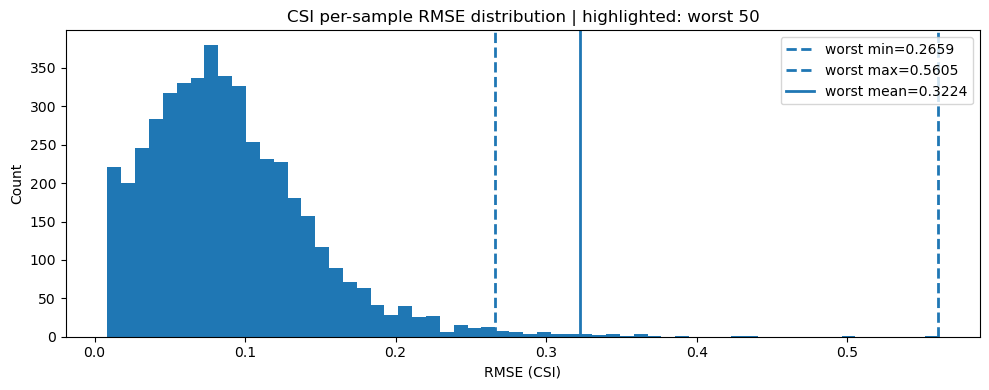

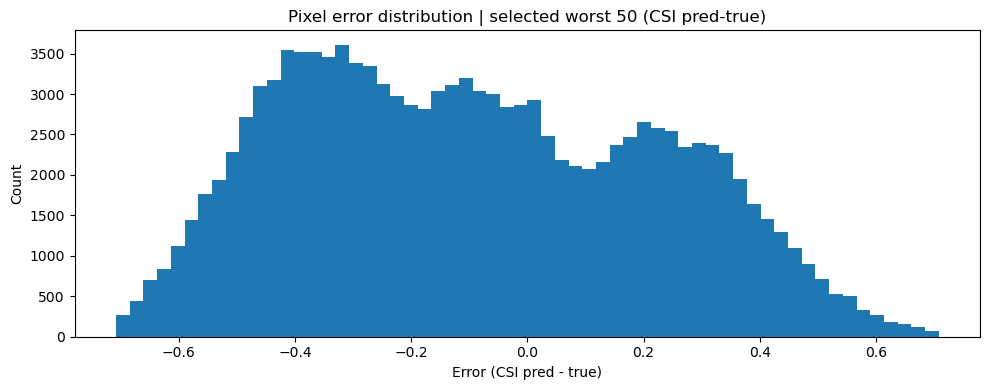

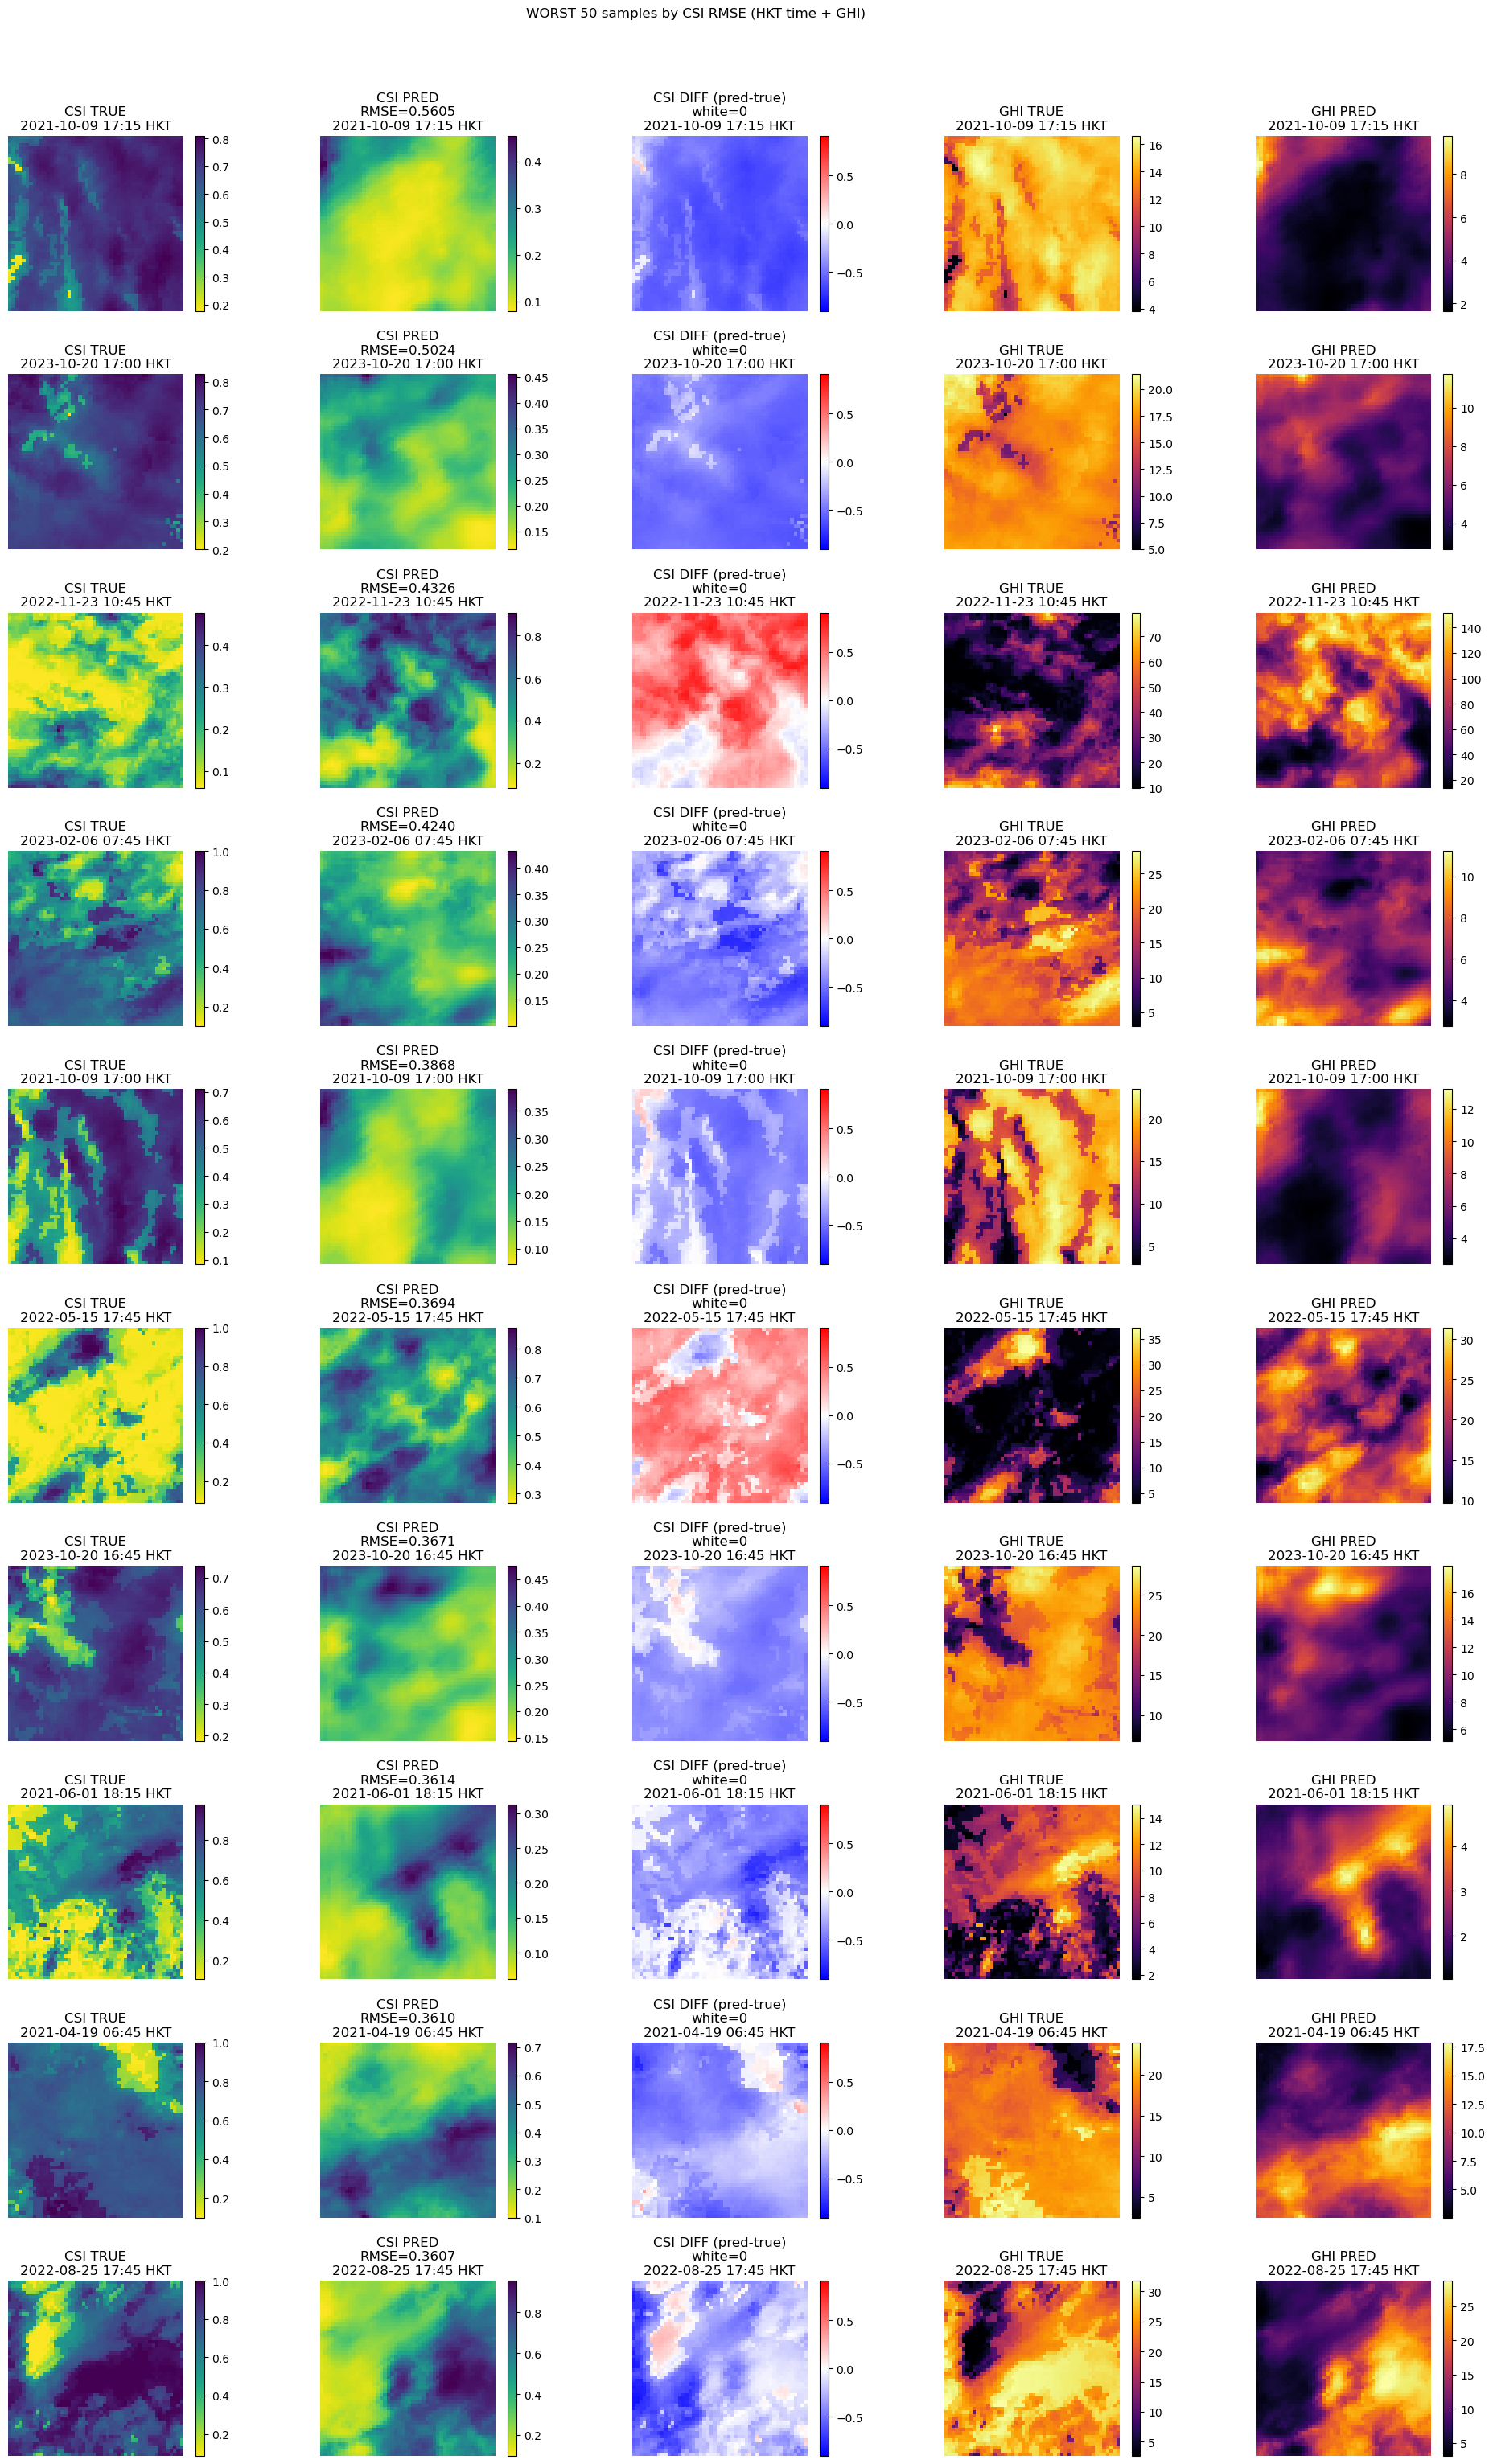

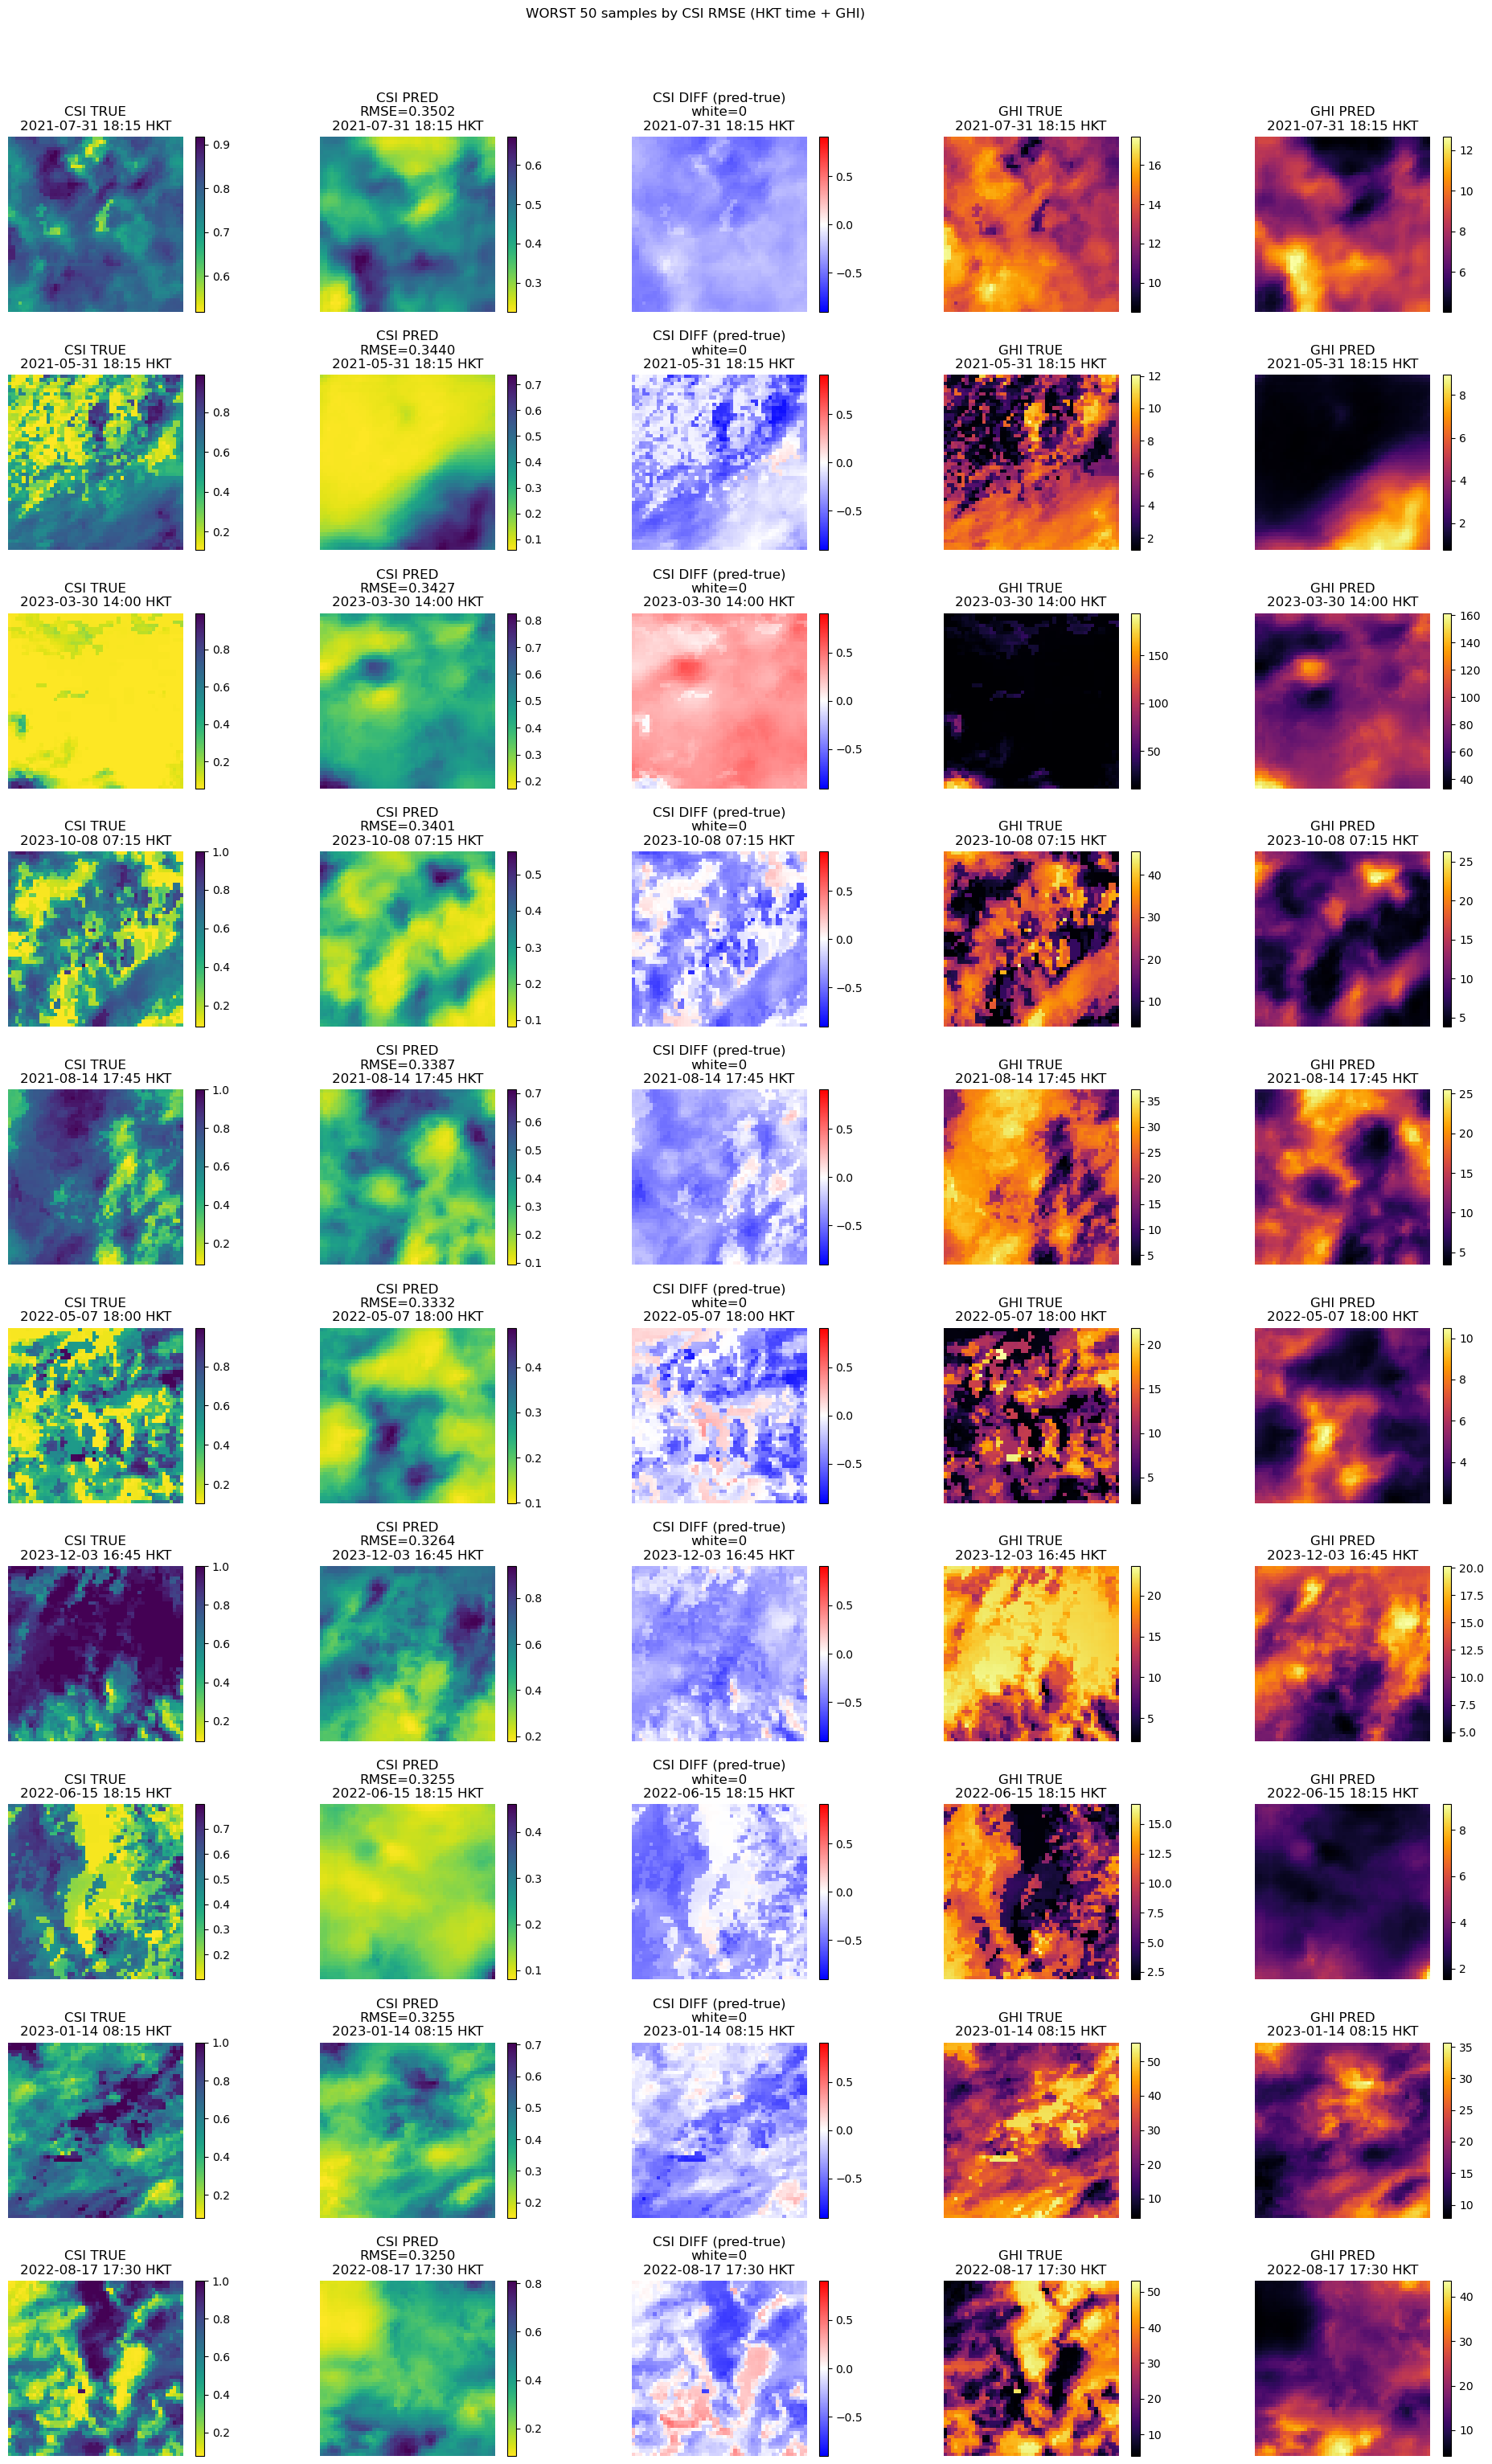

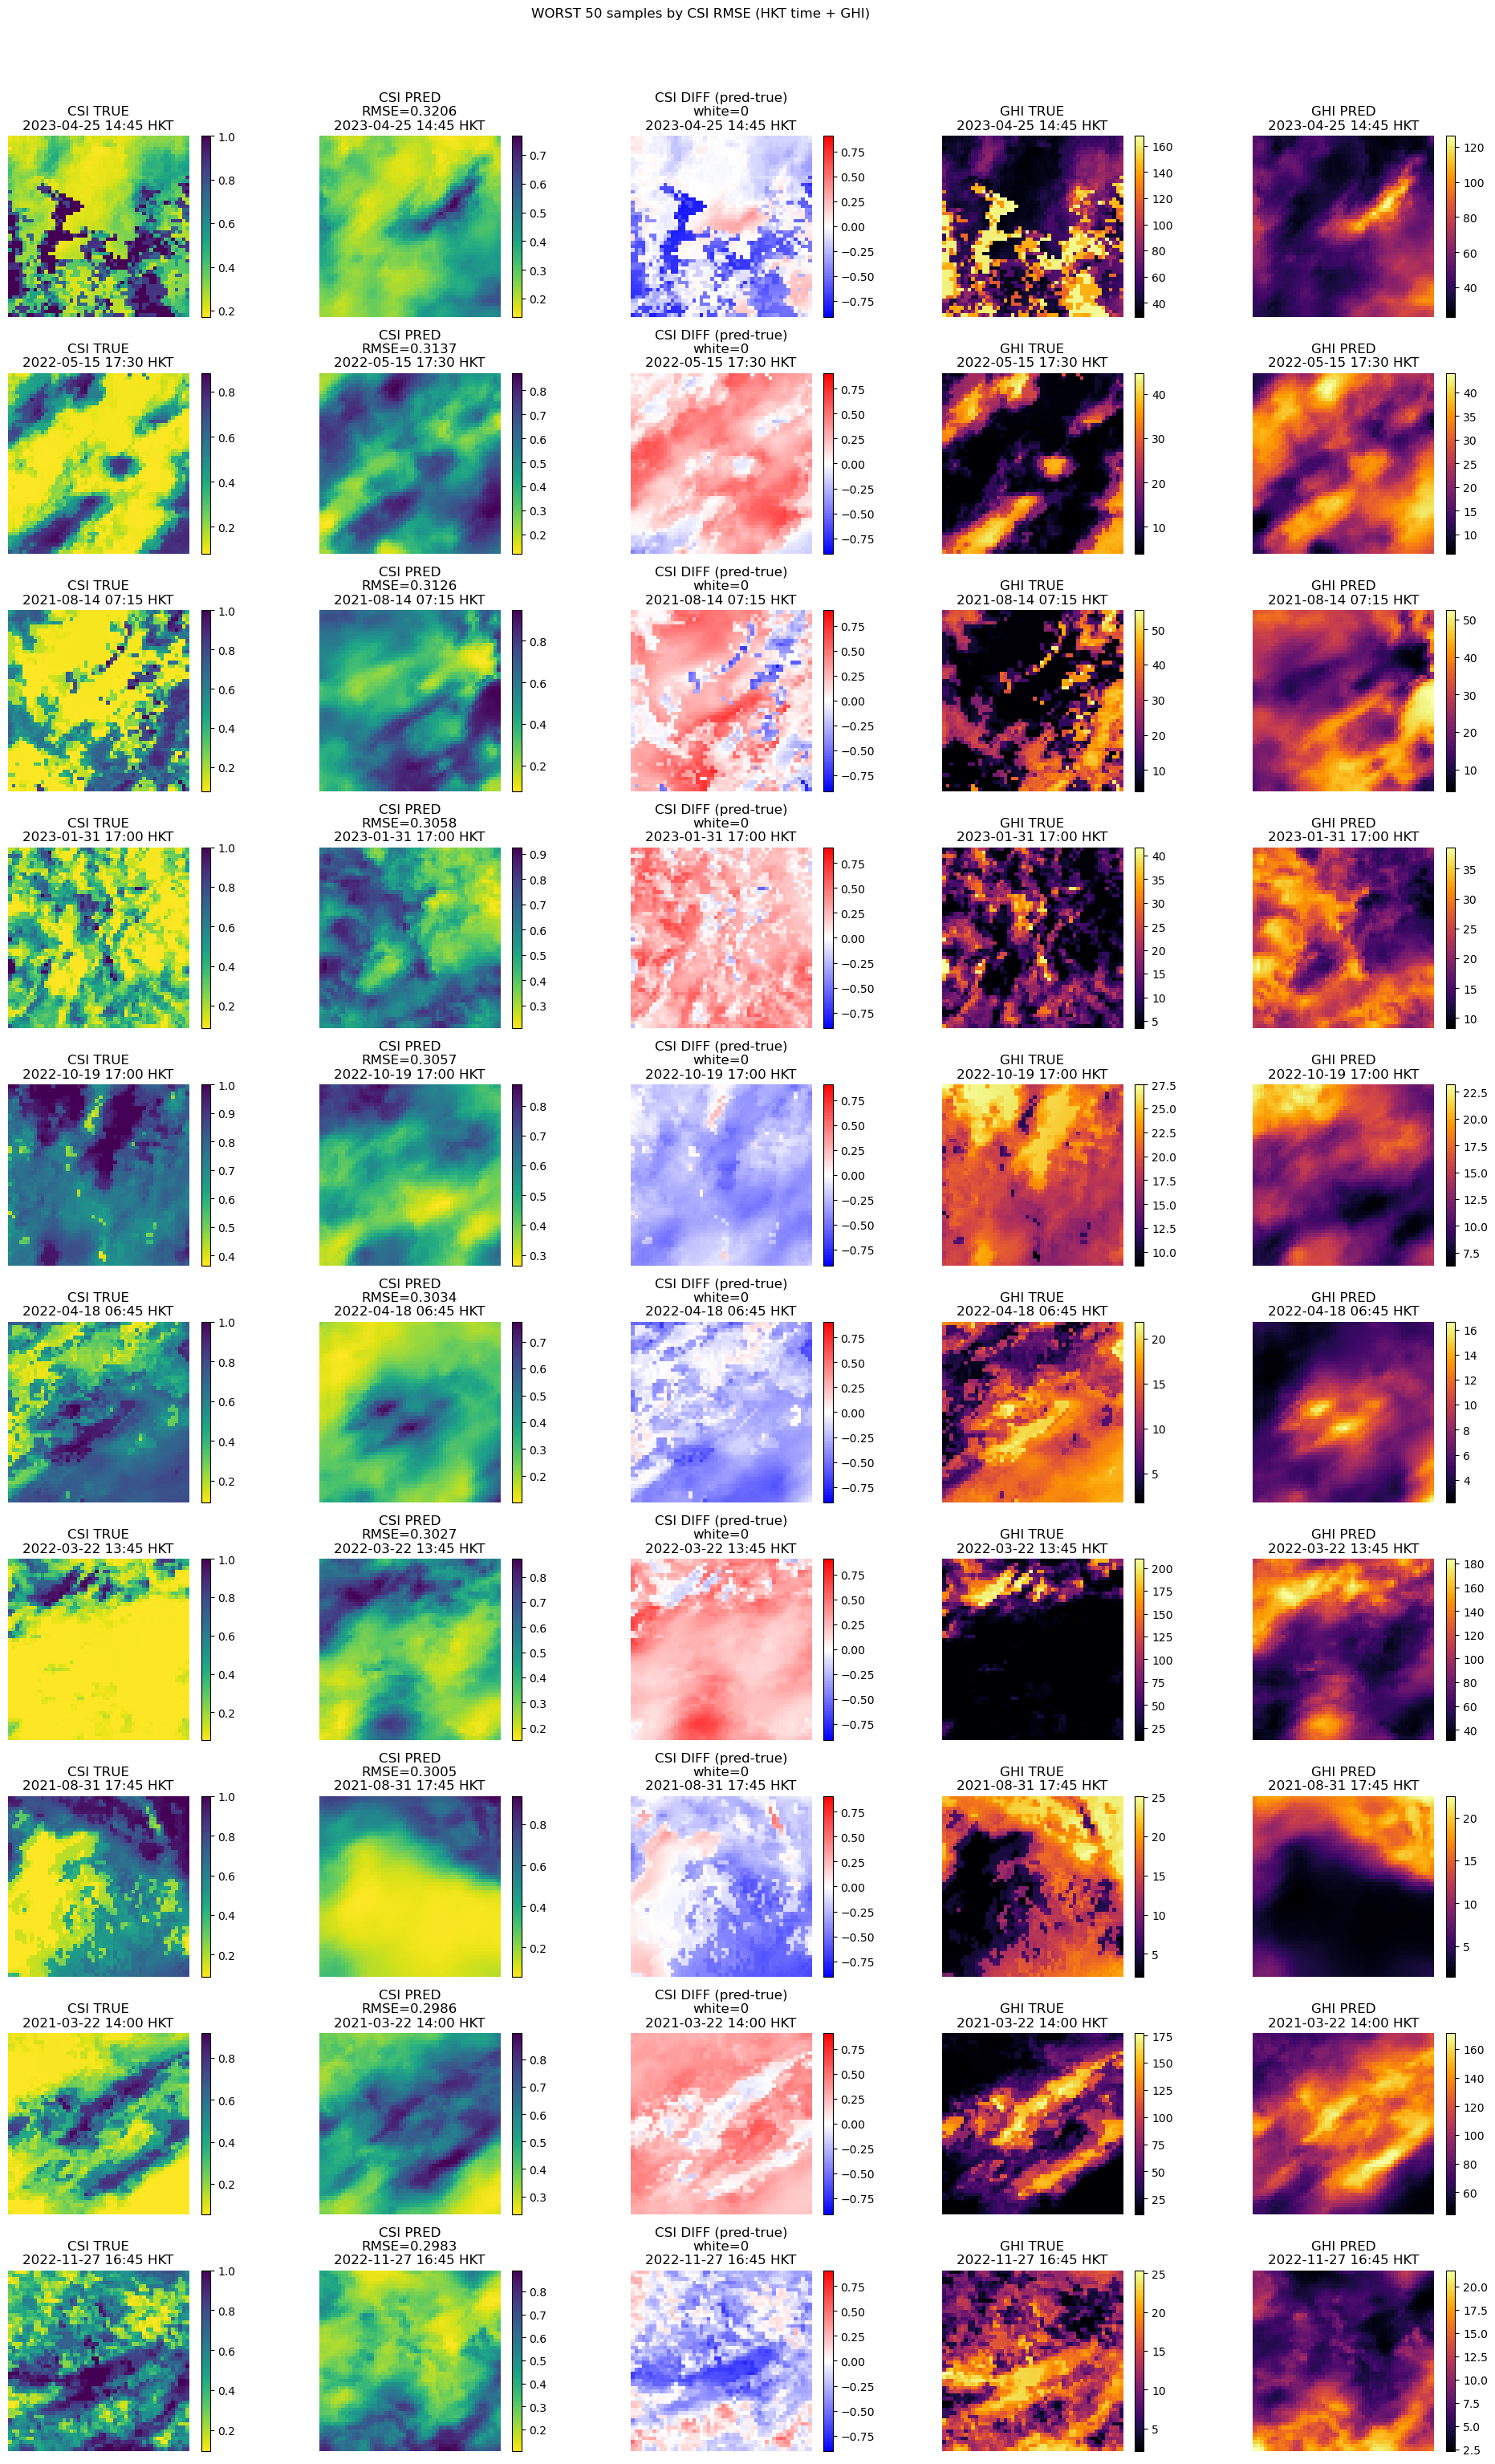

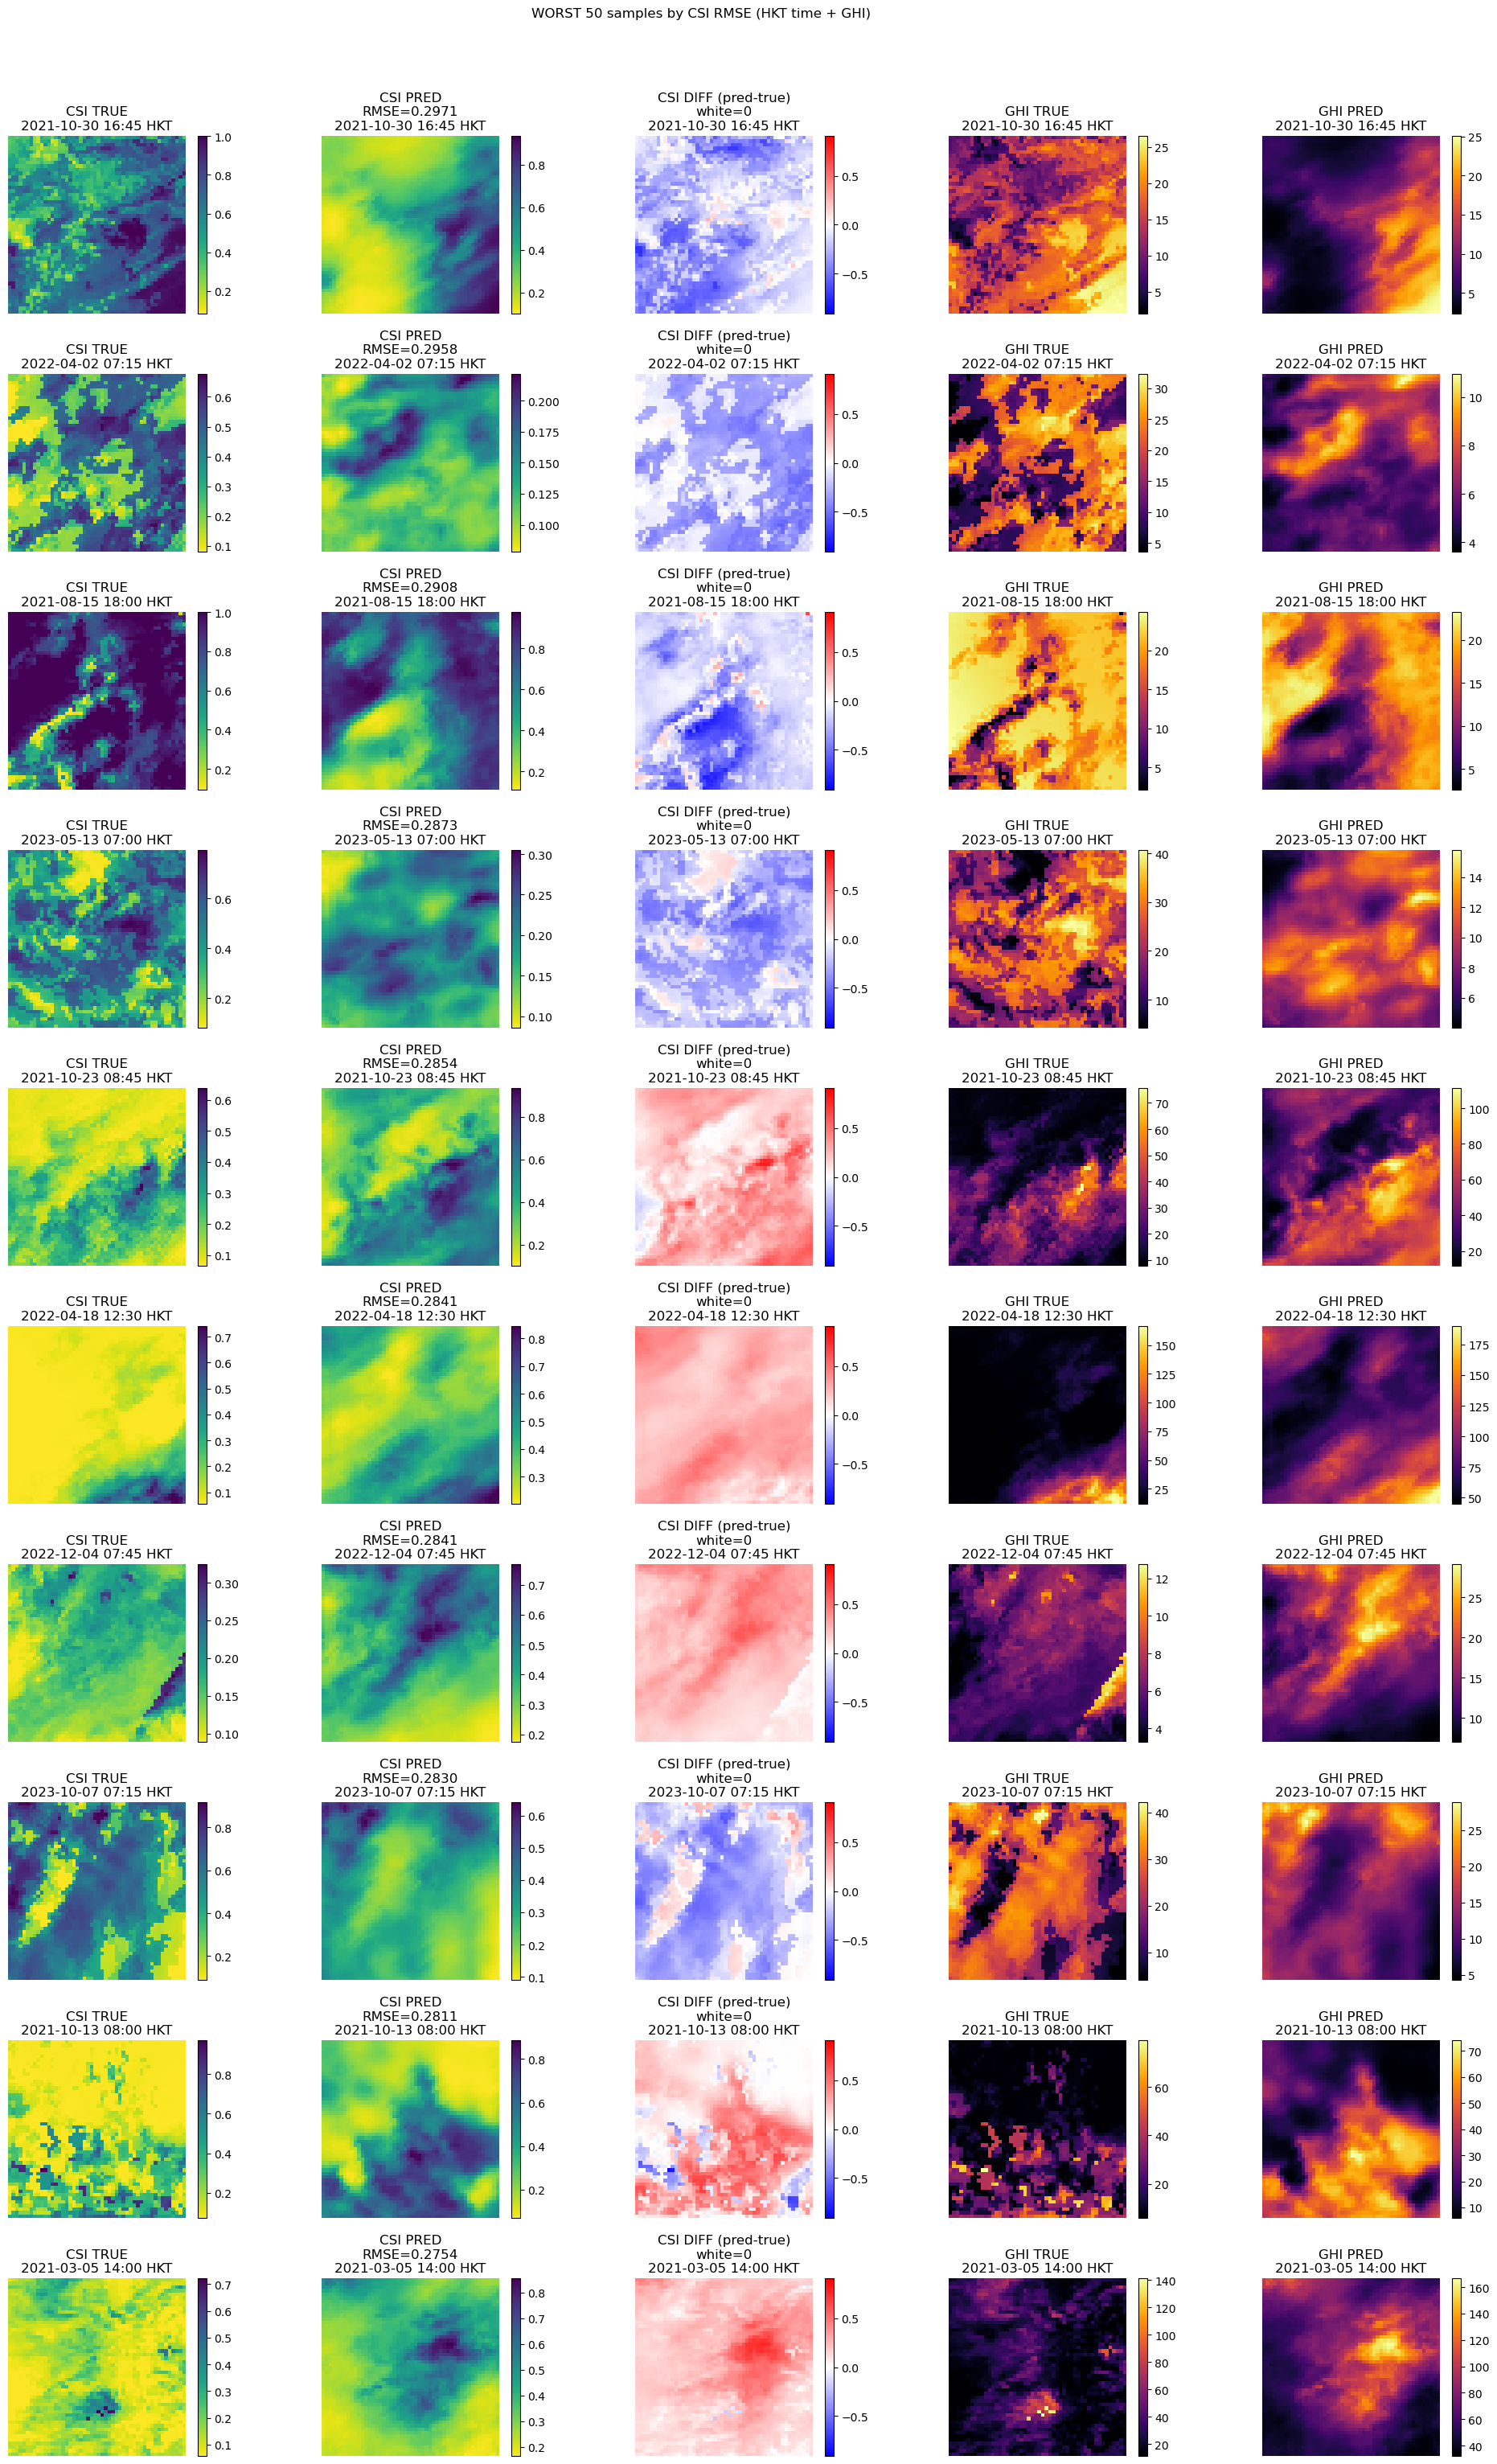

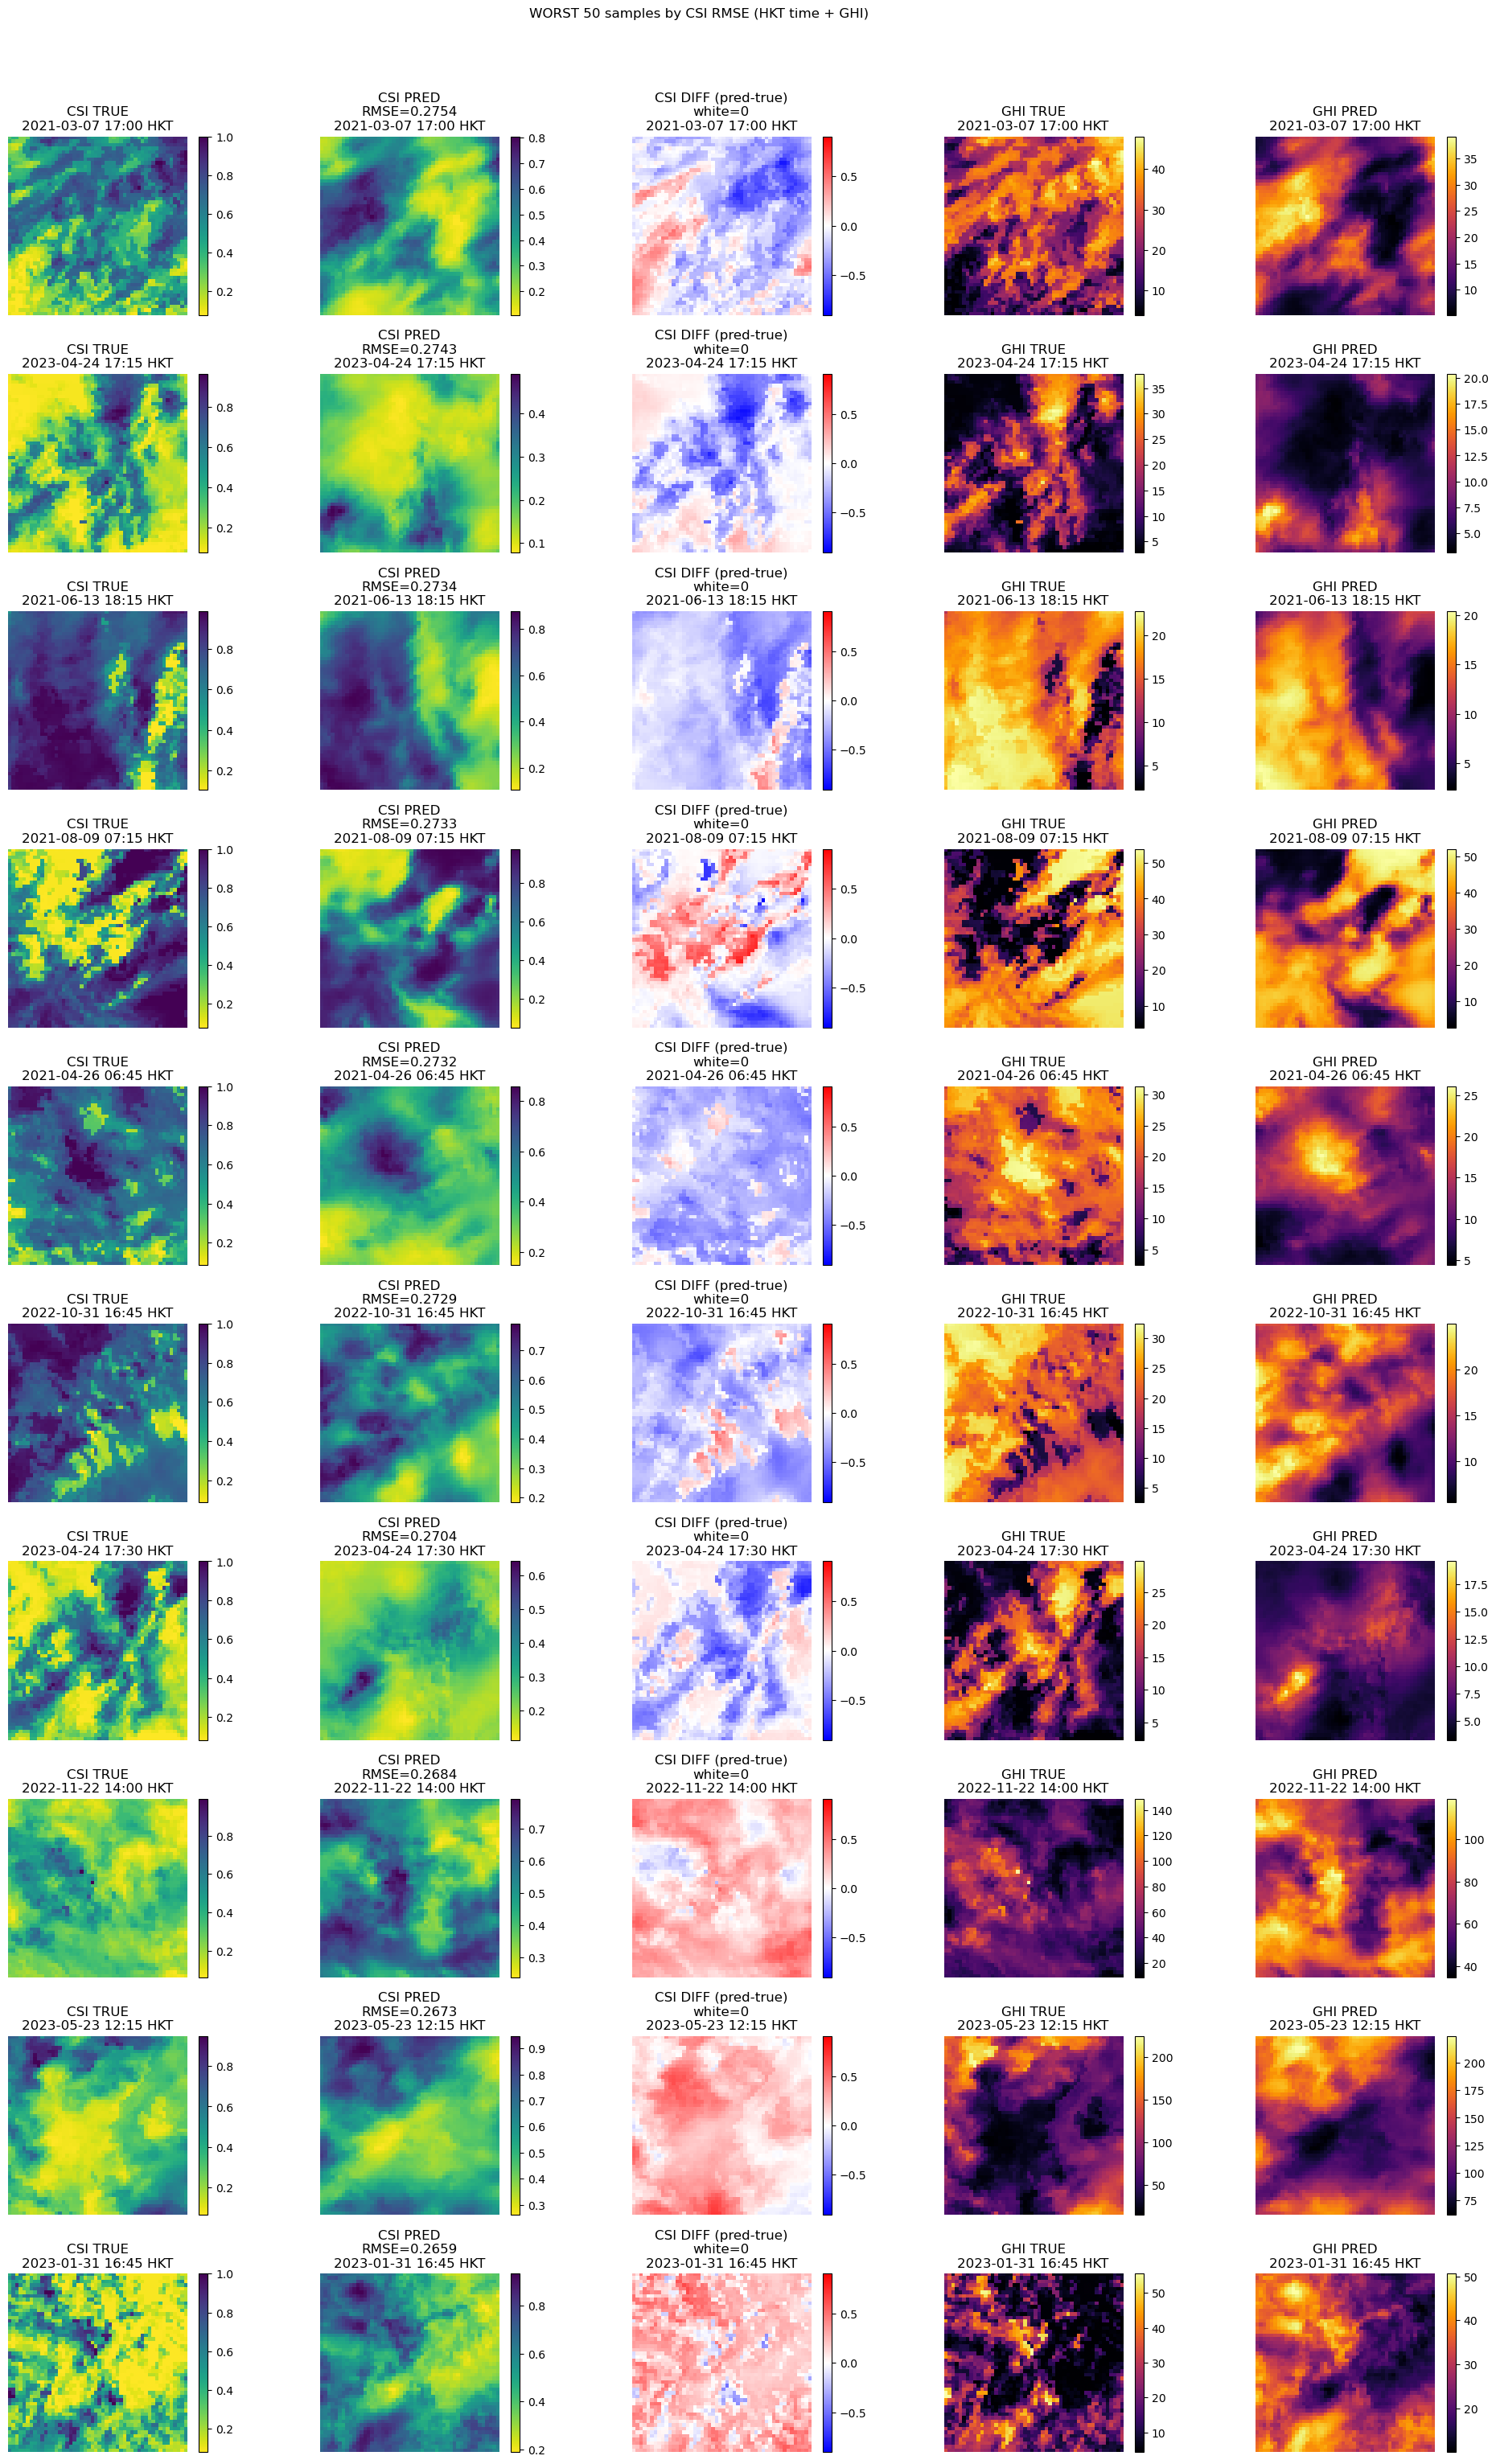

In [47]:
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="worst",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)


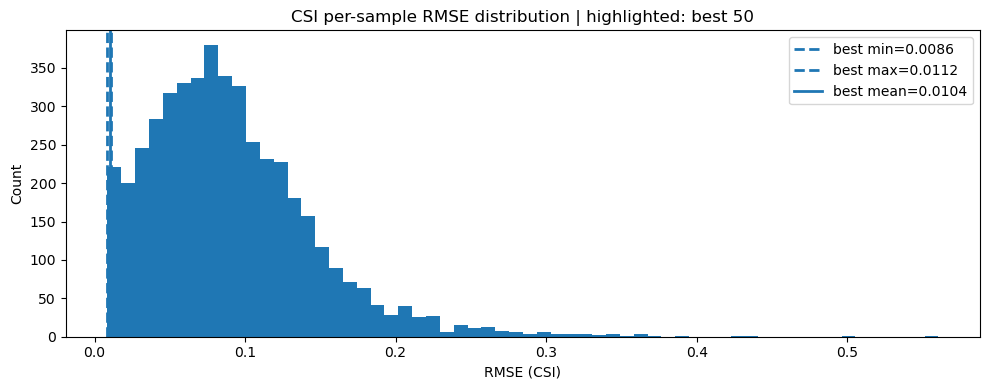

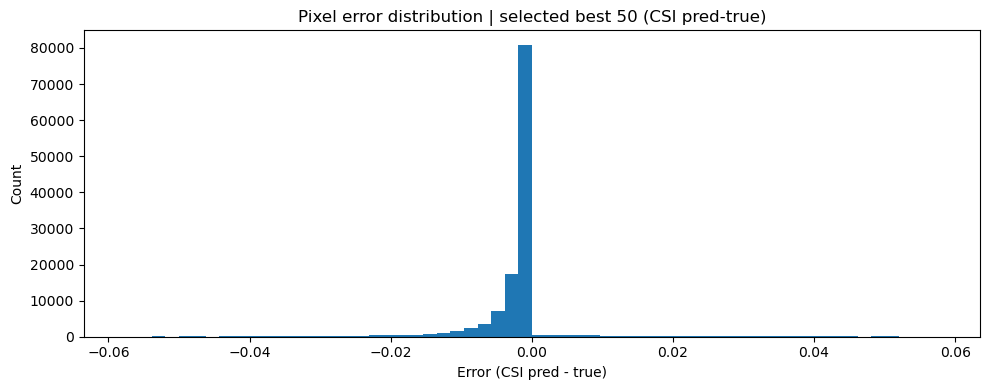

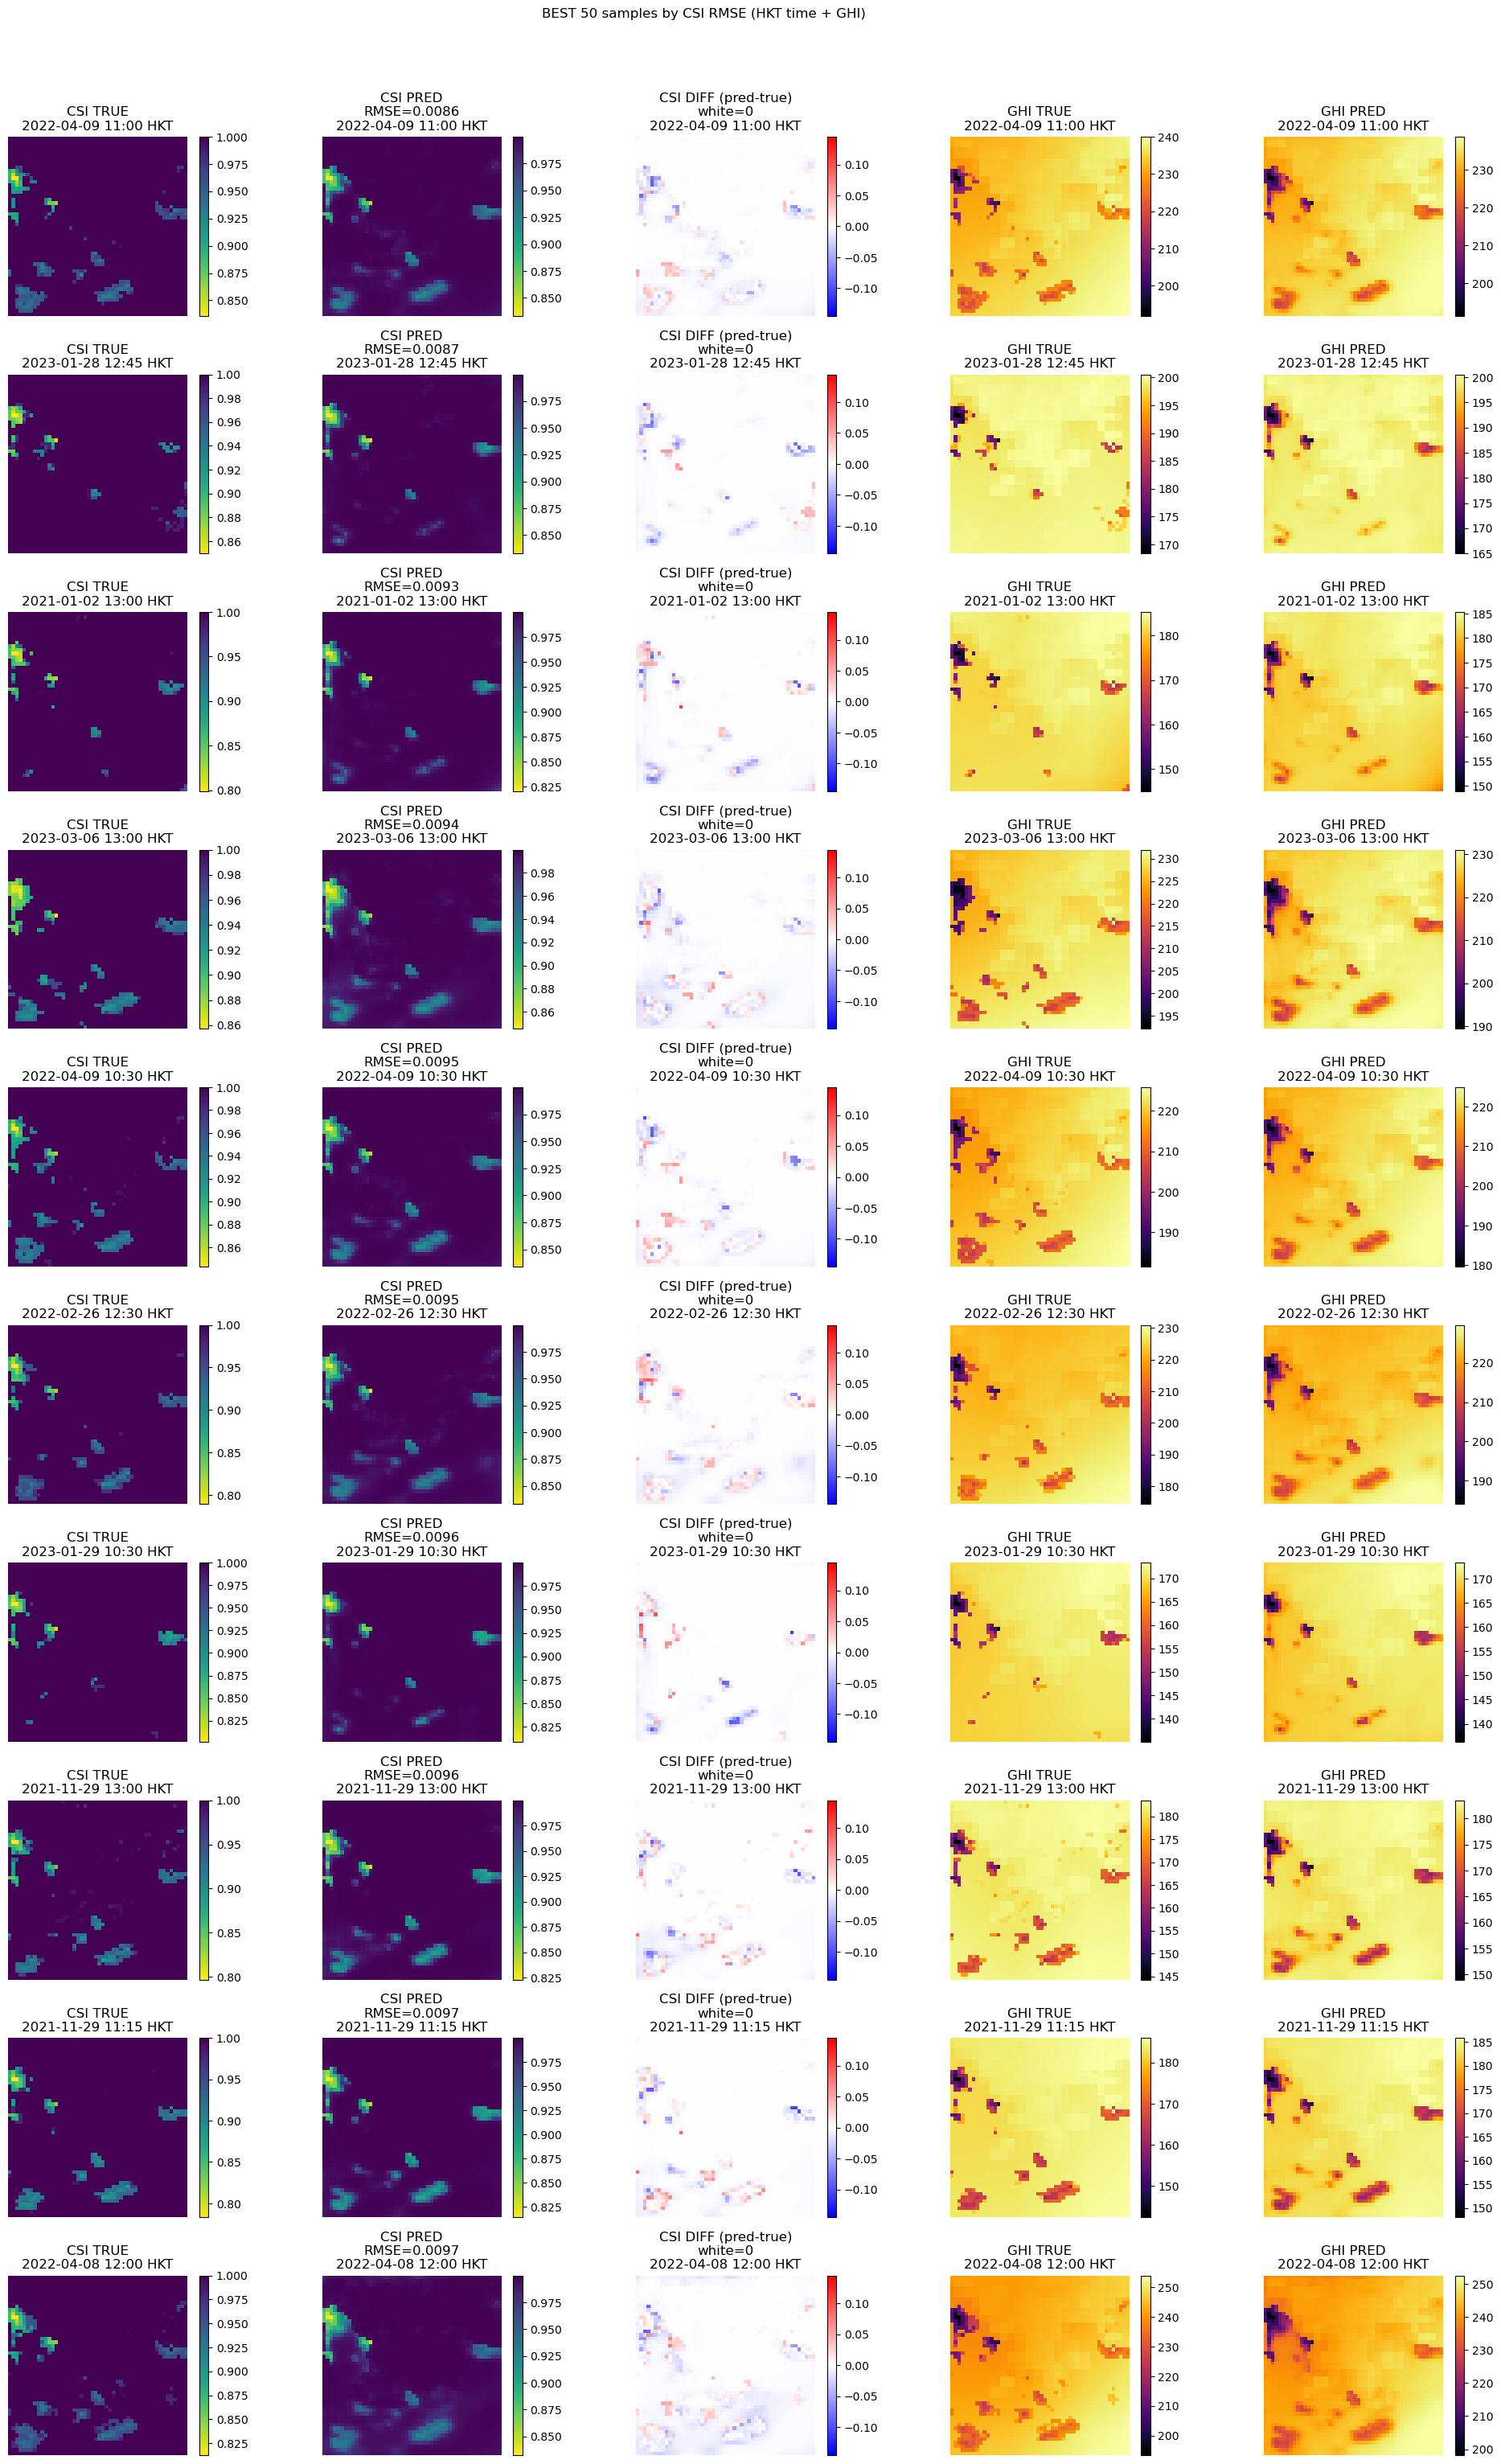

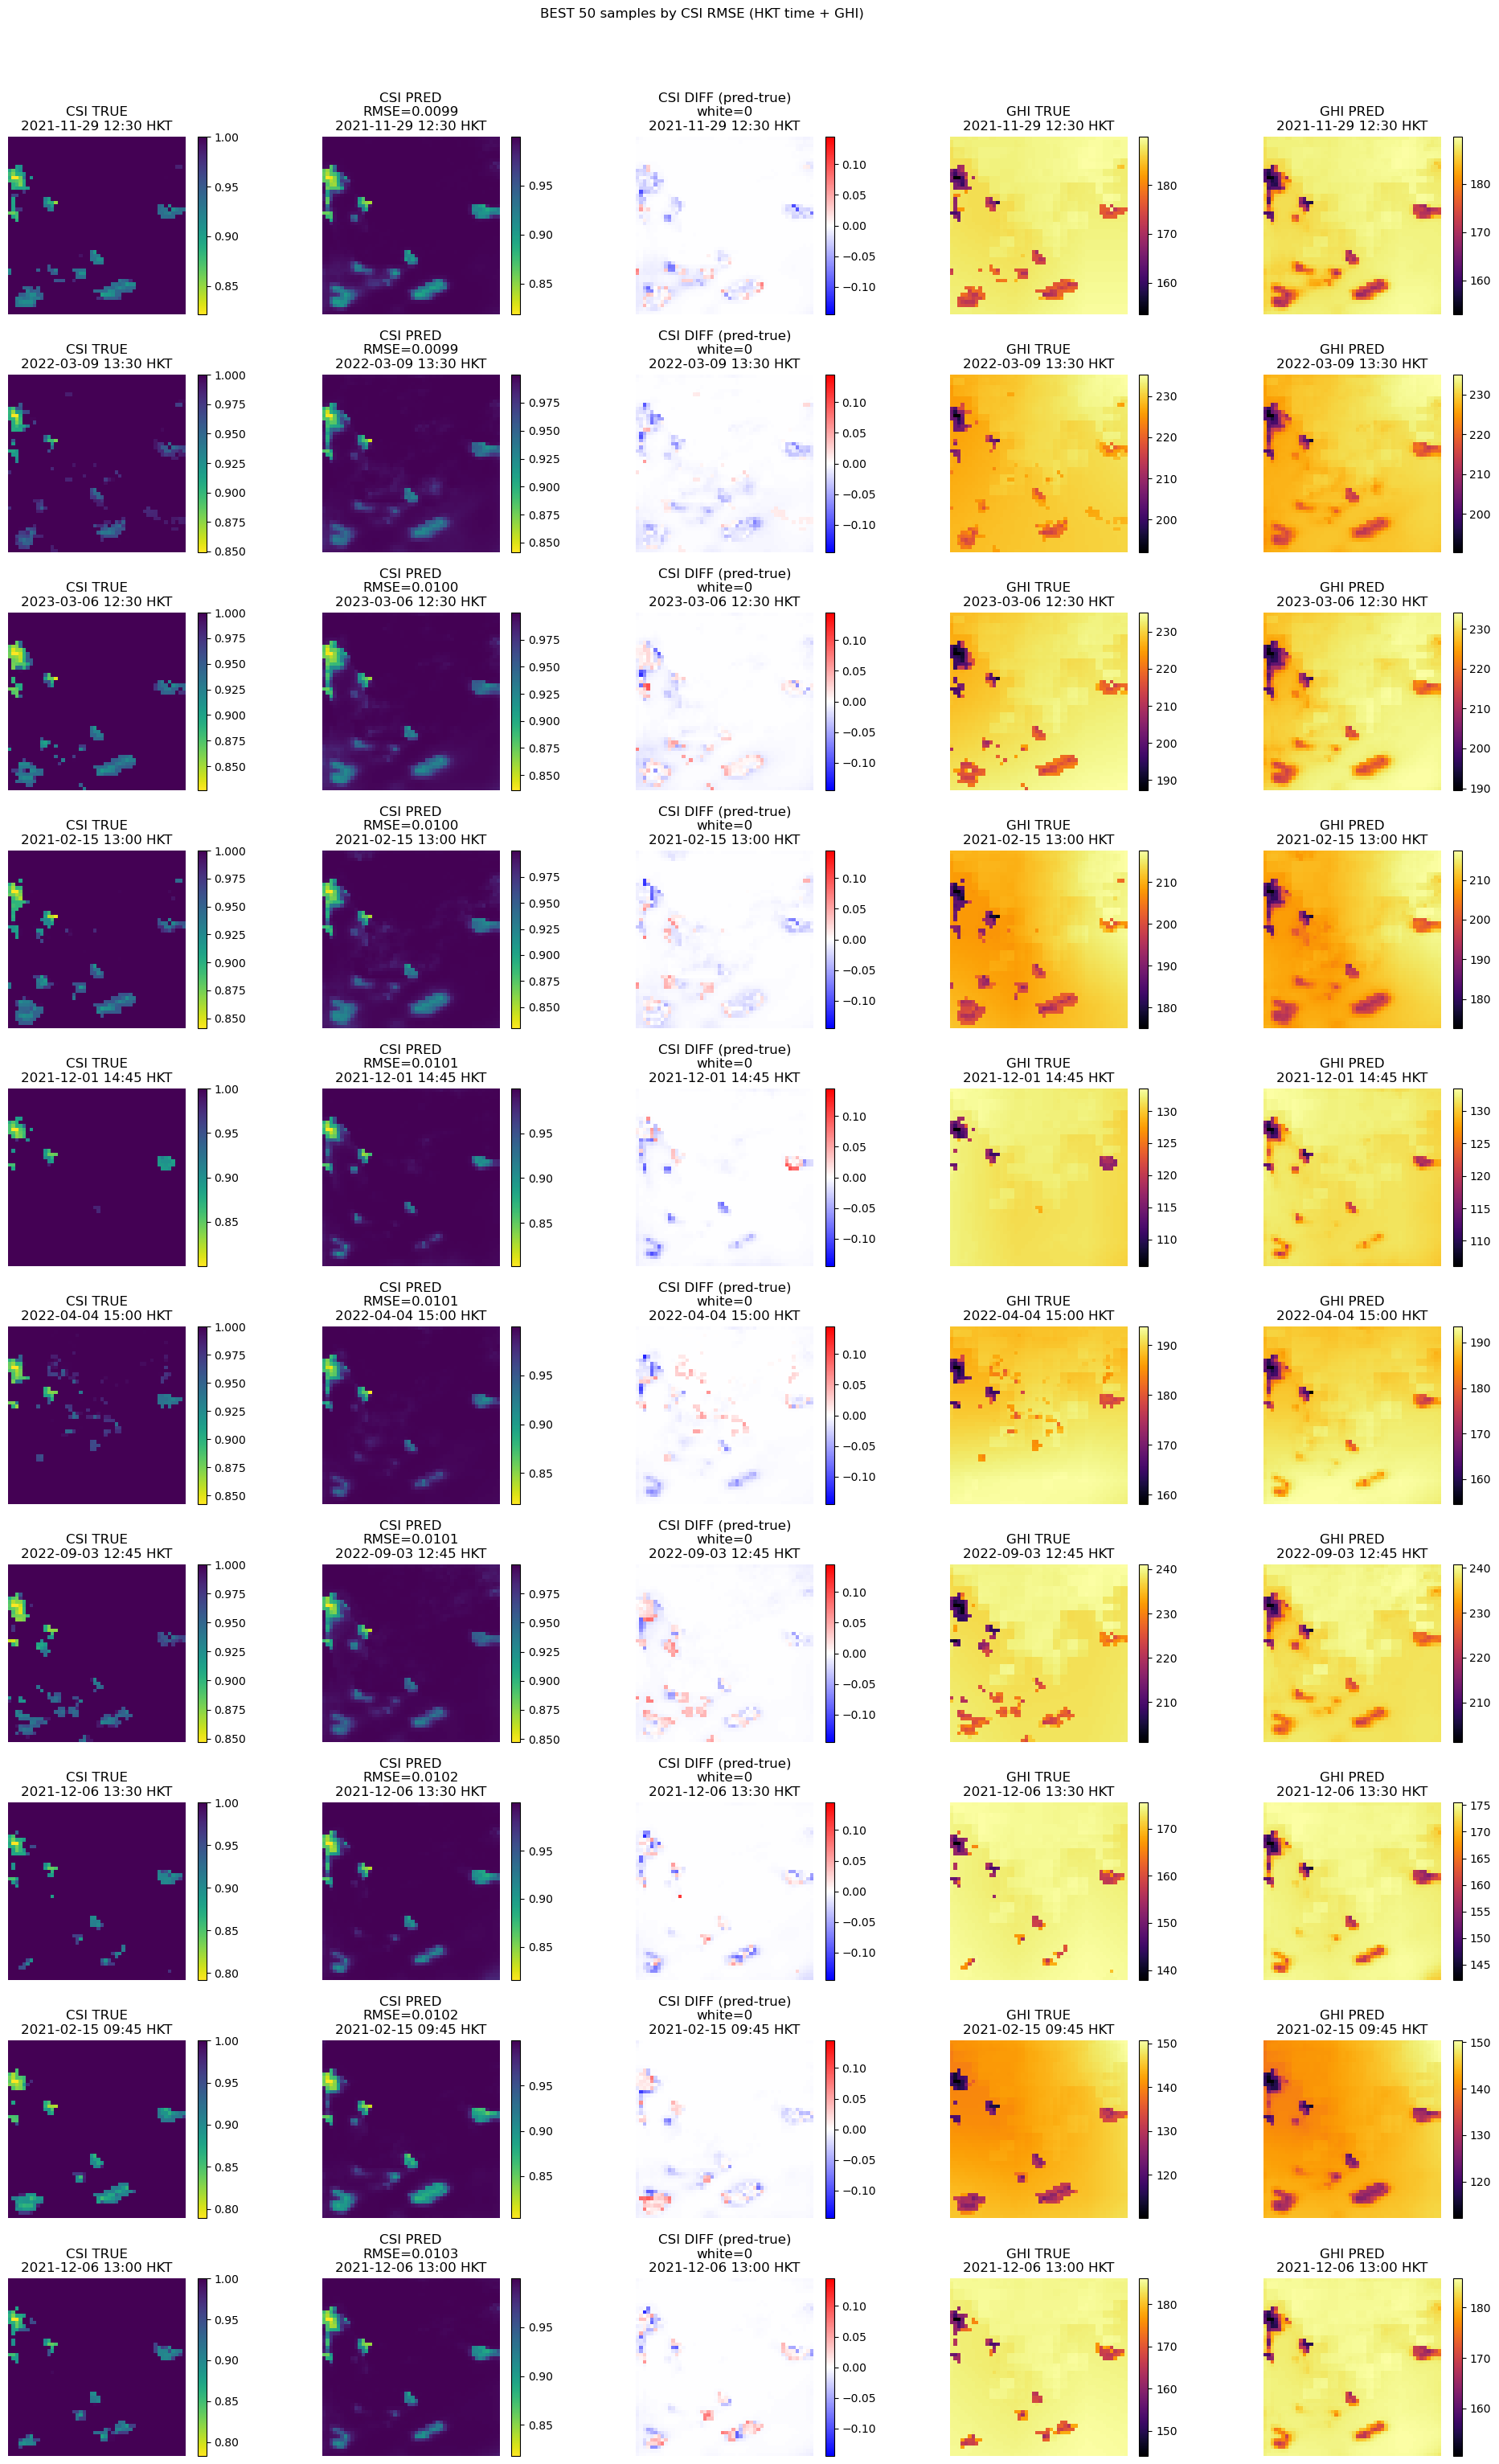

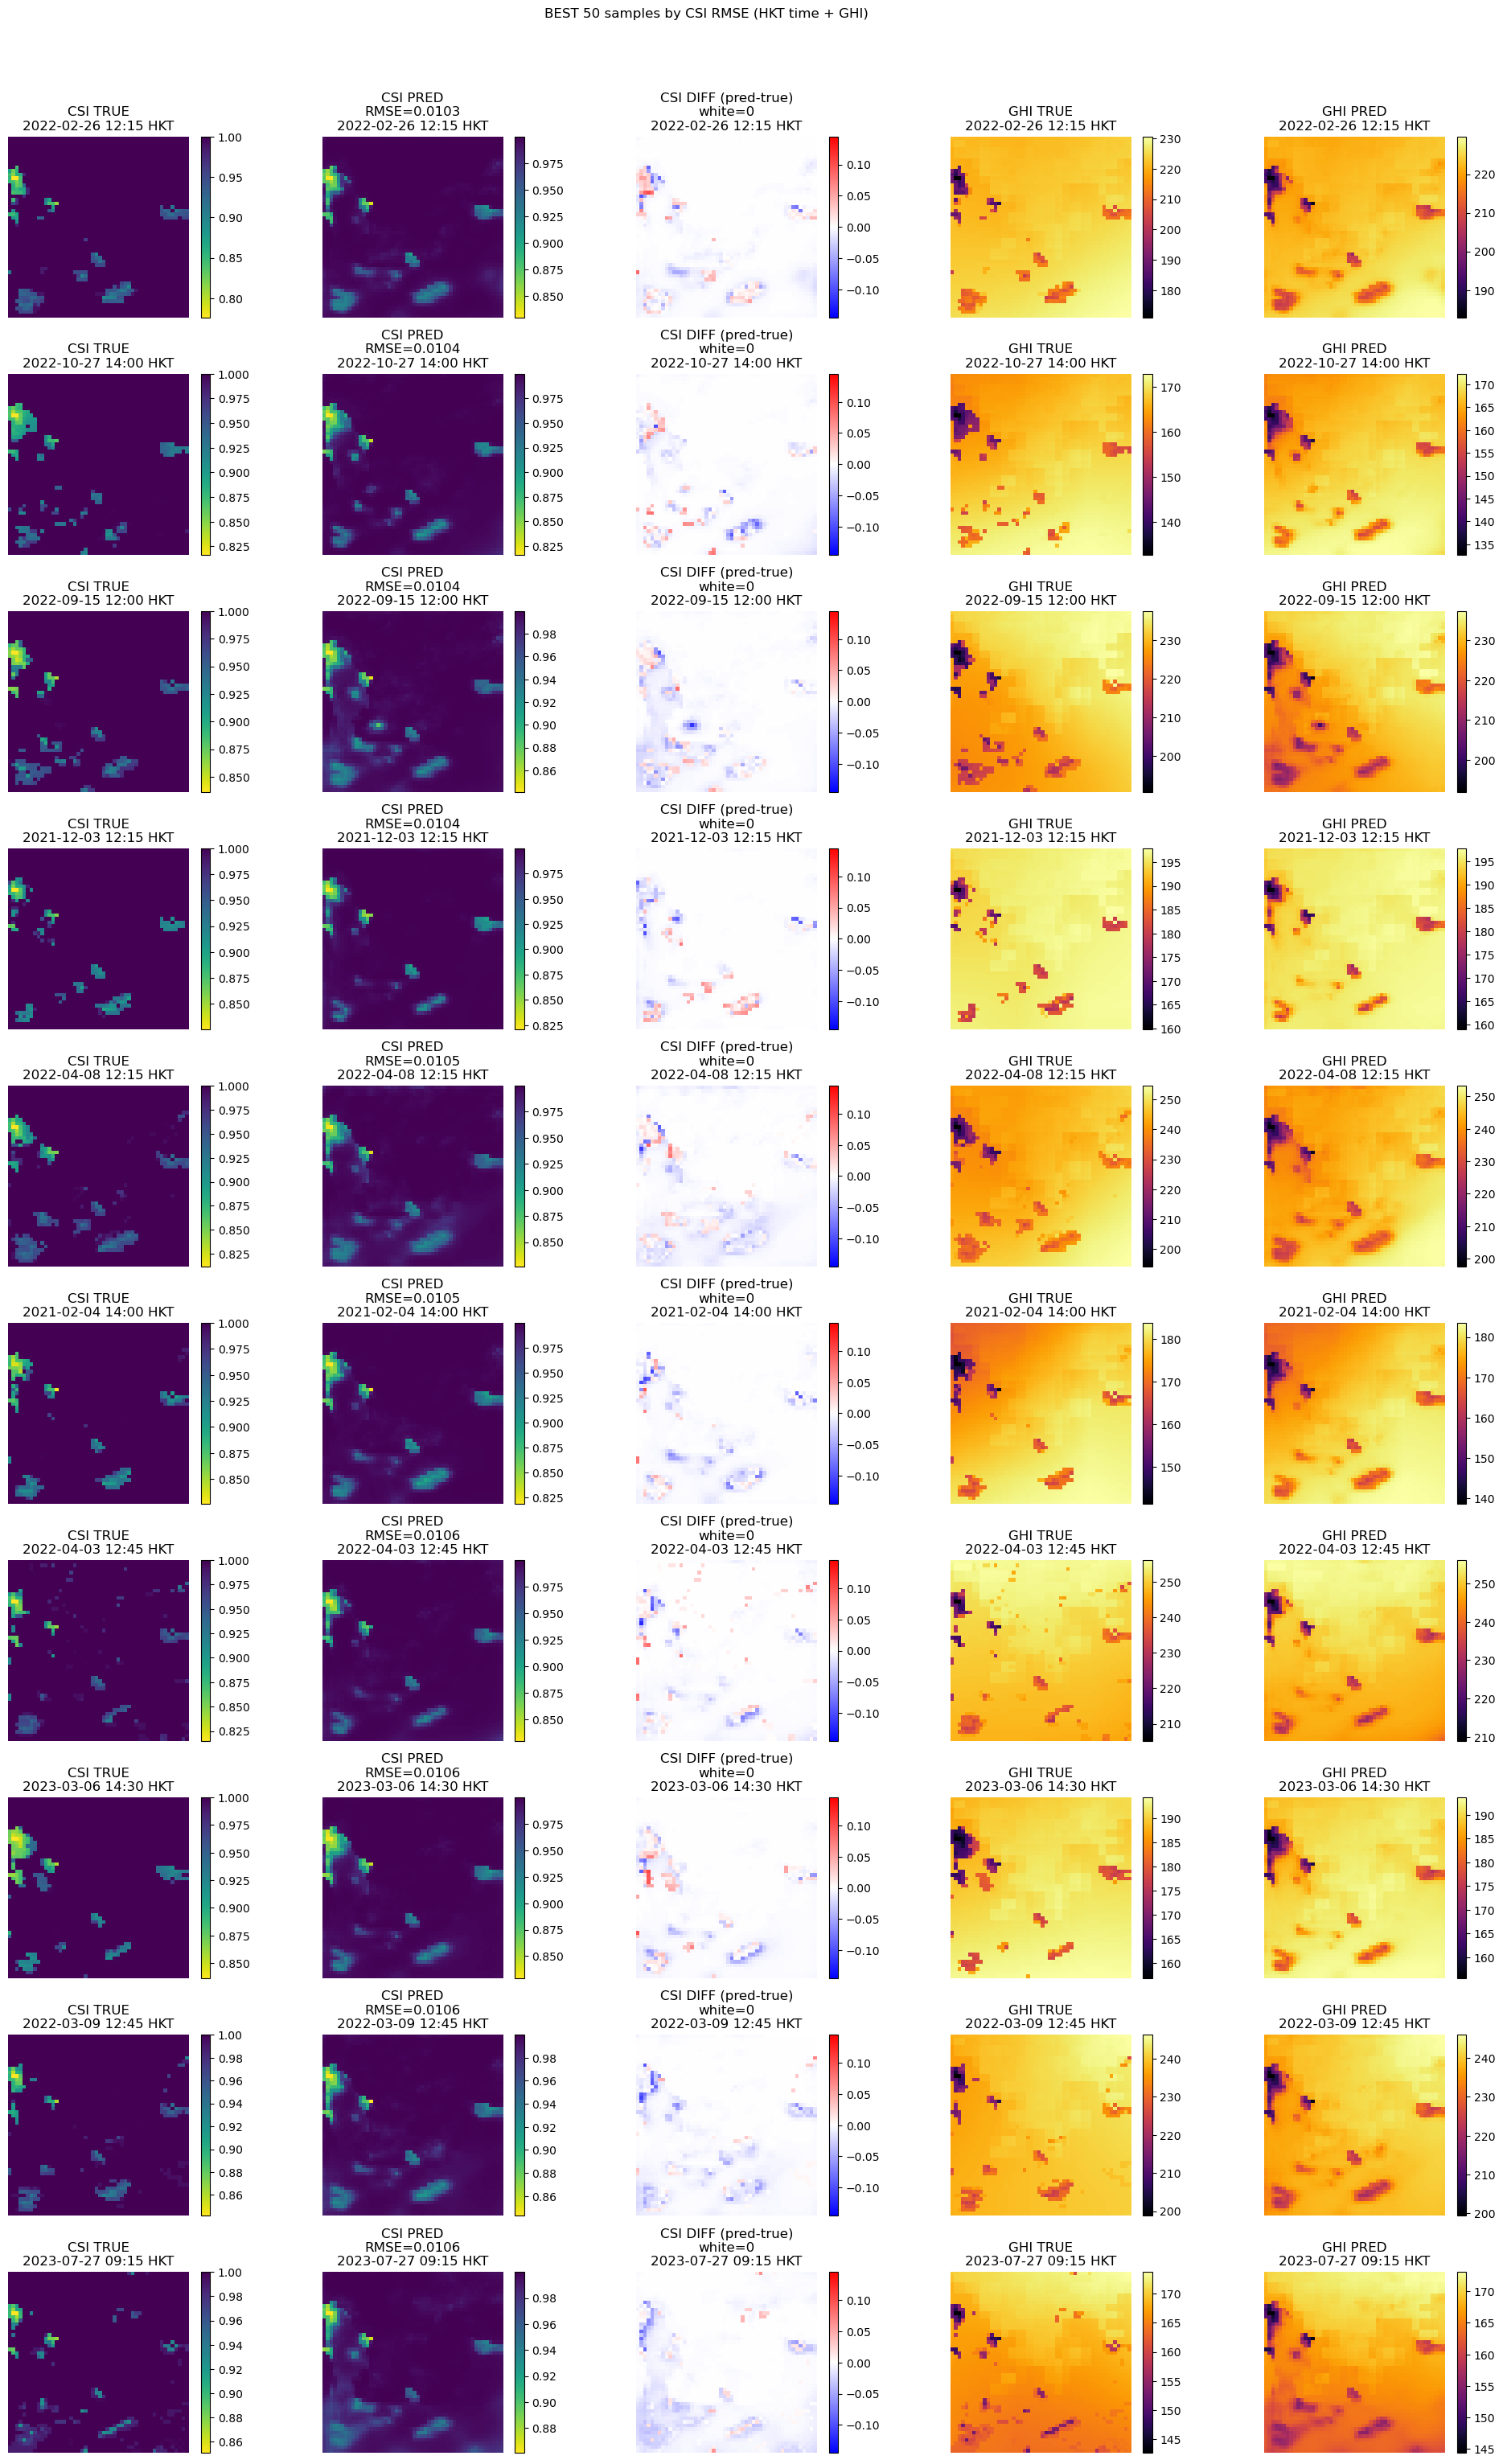

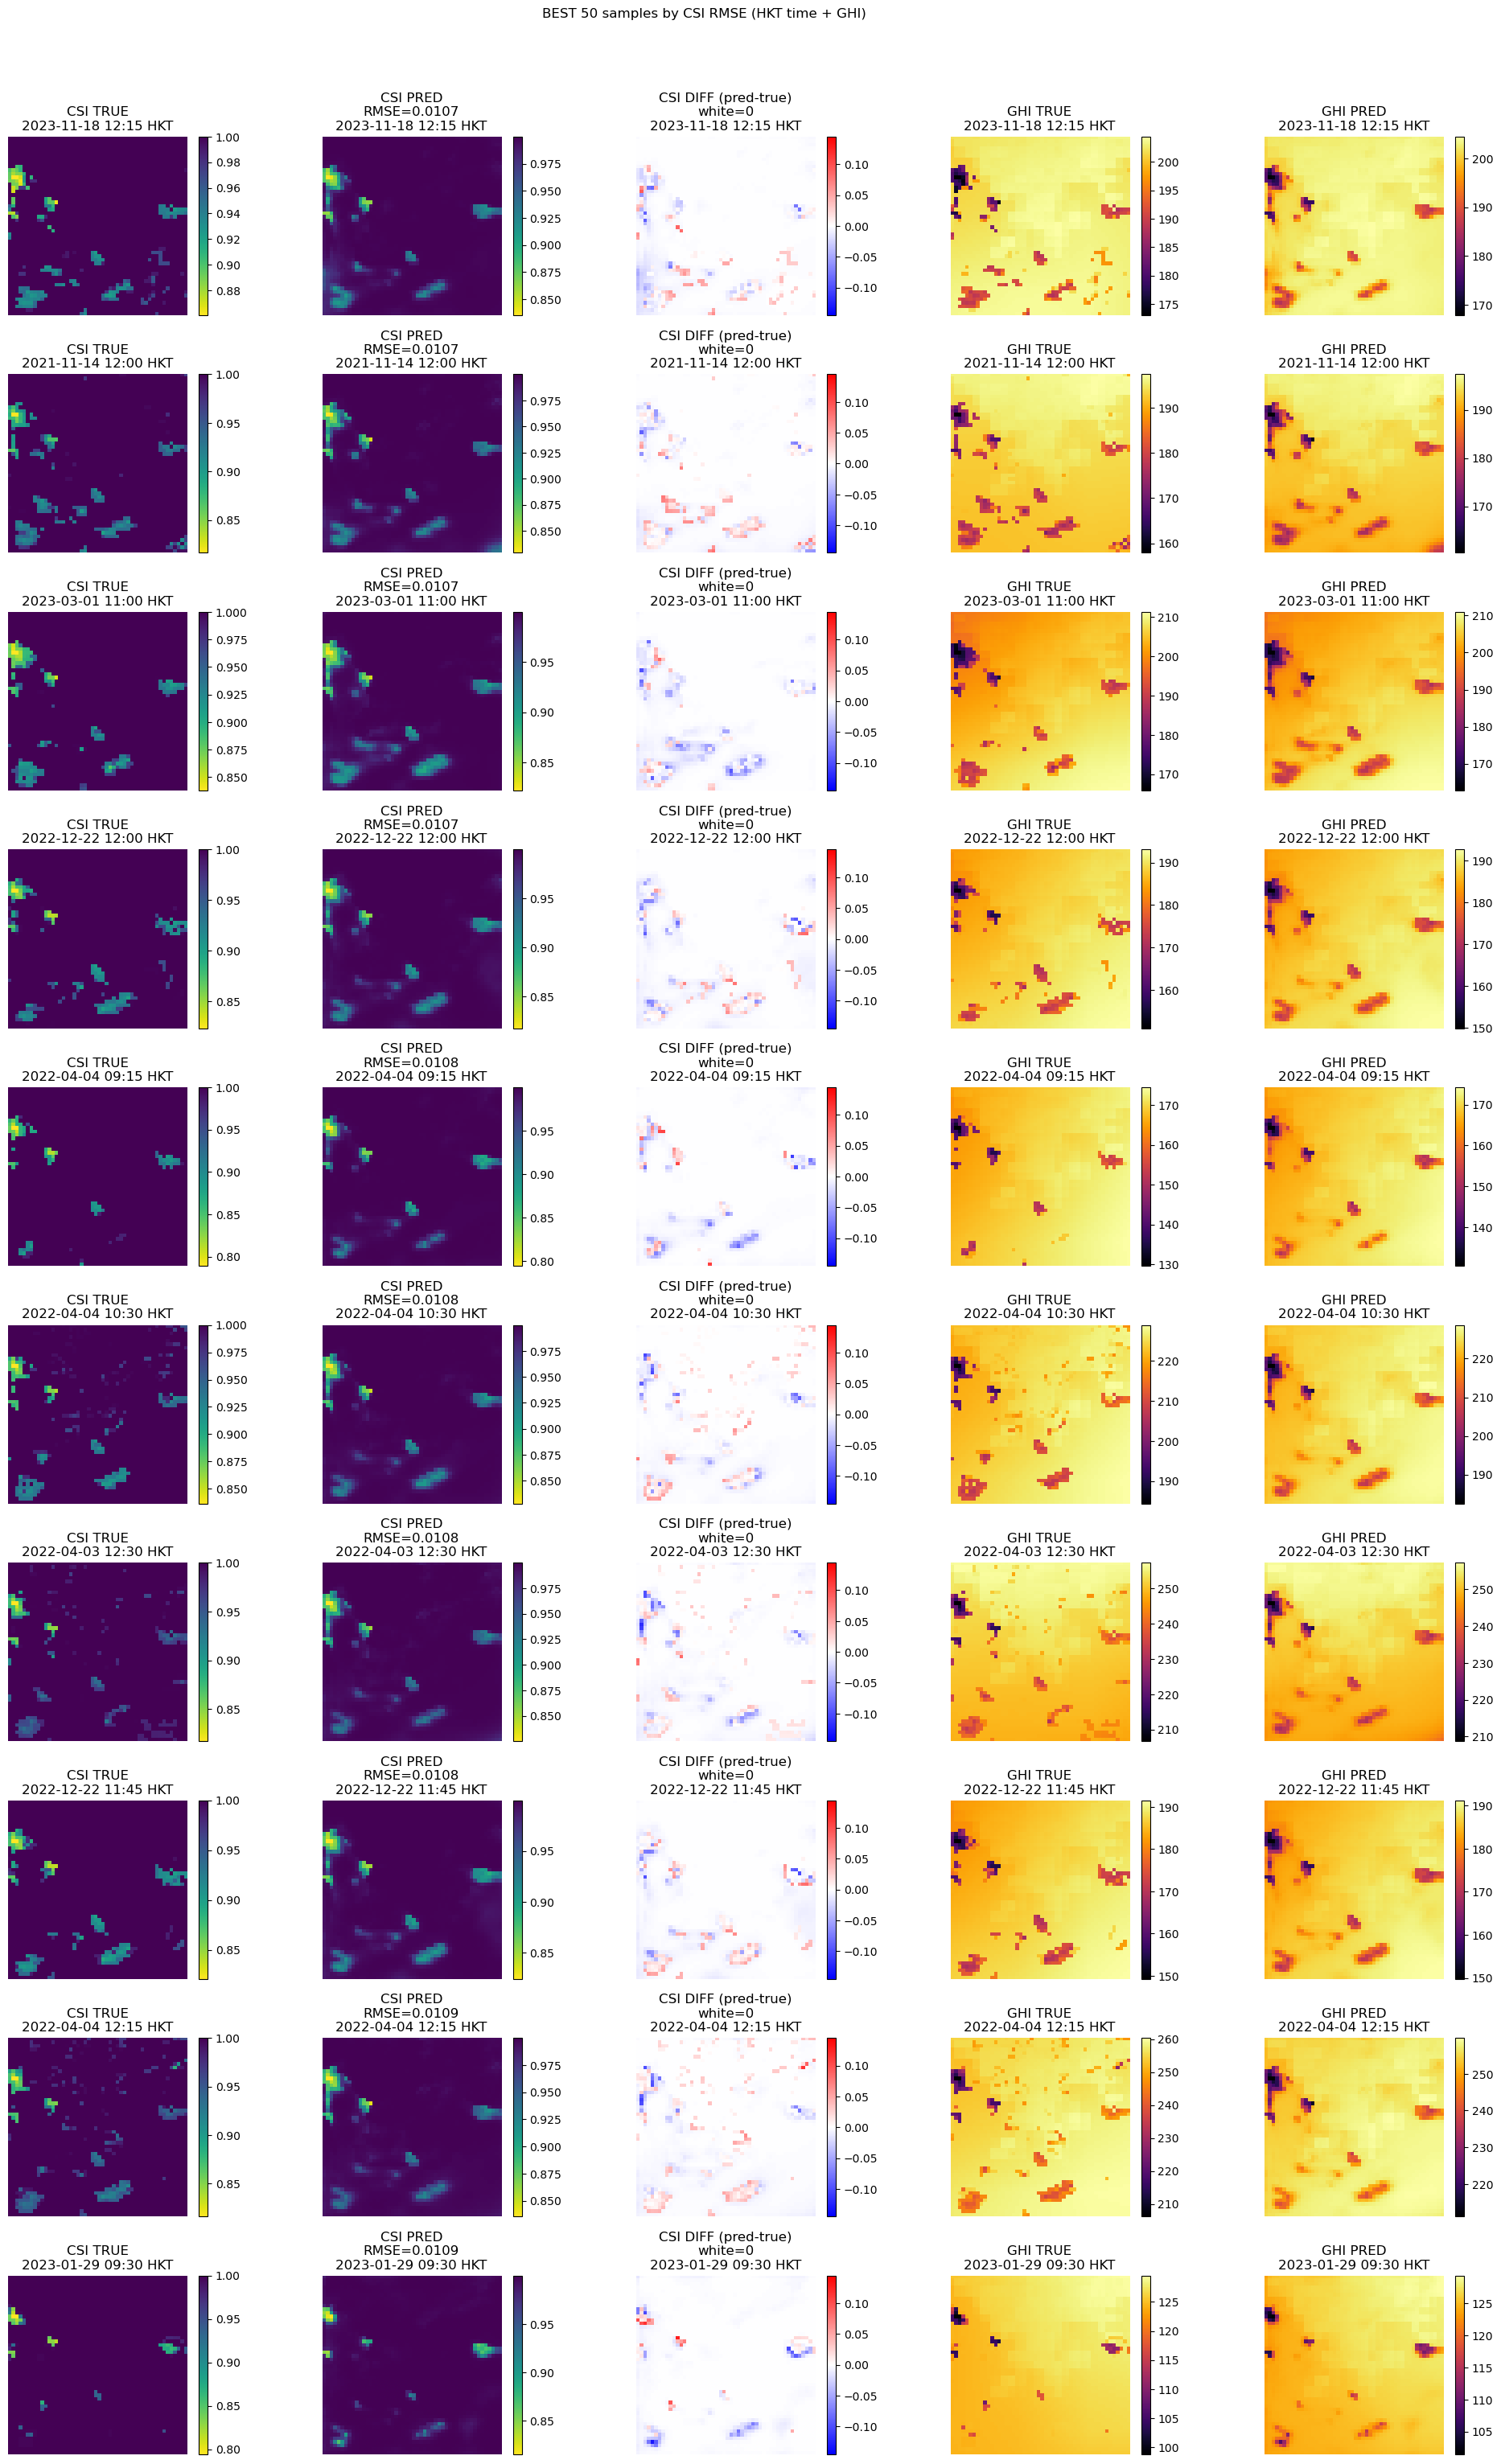

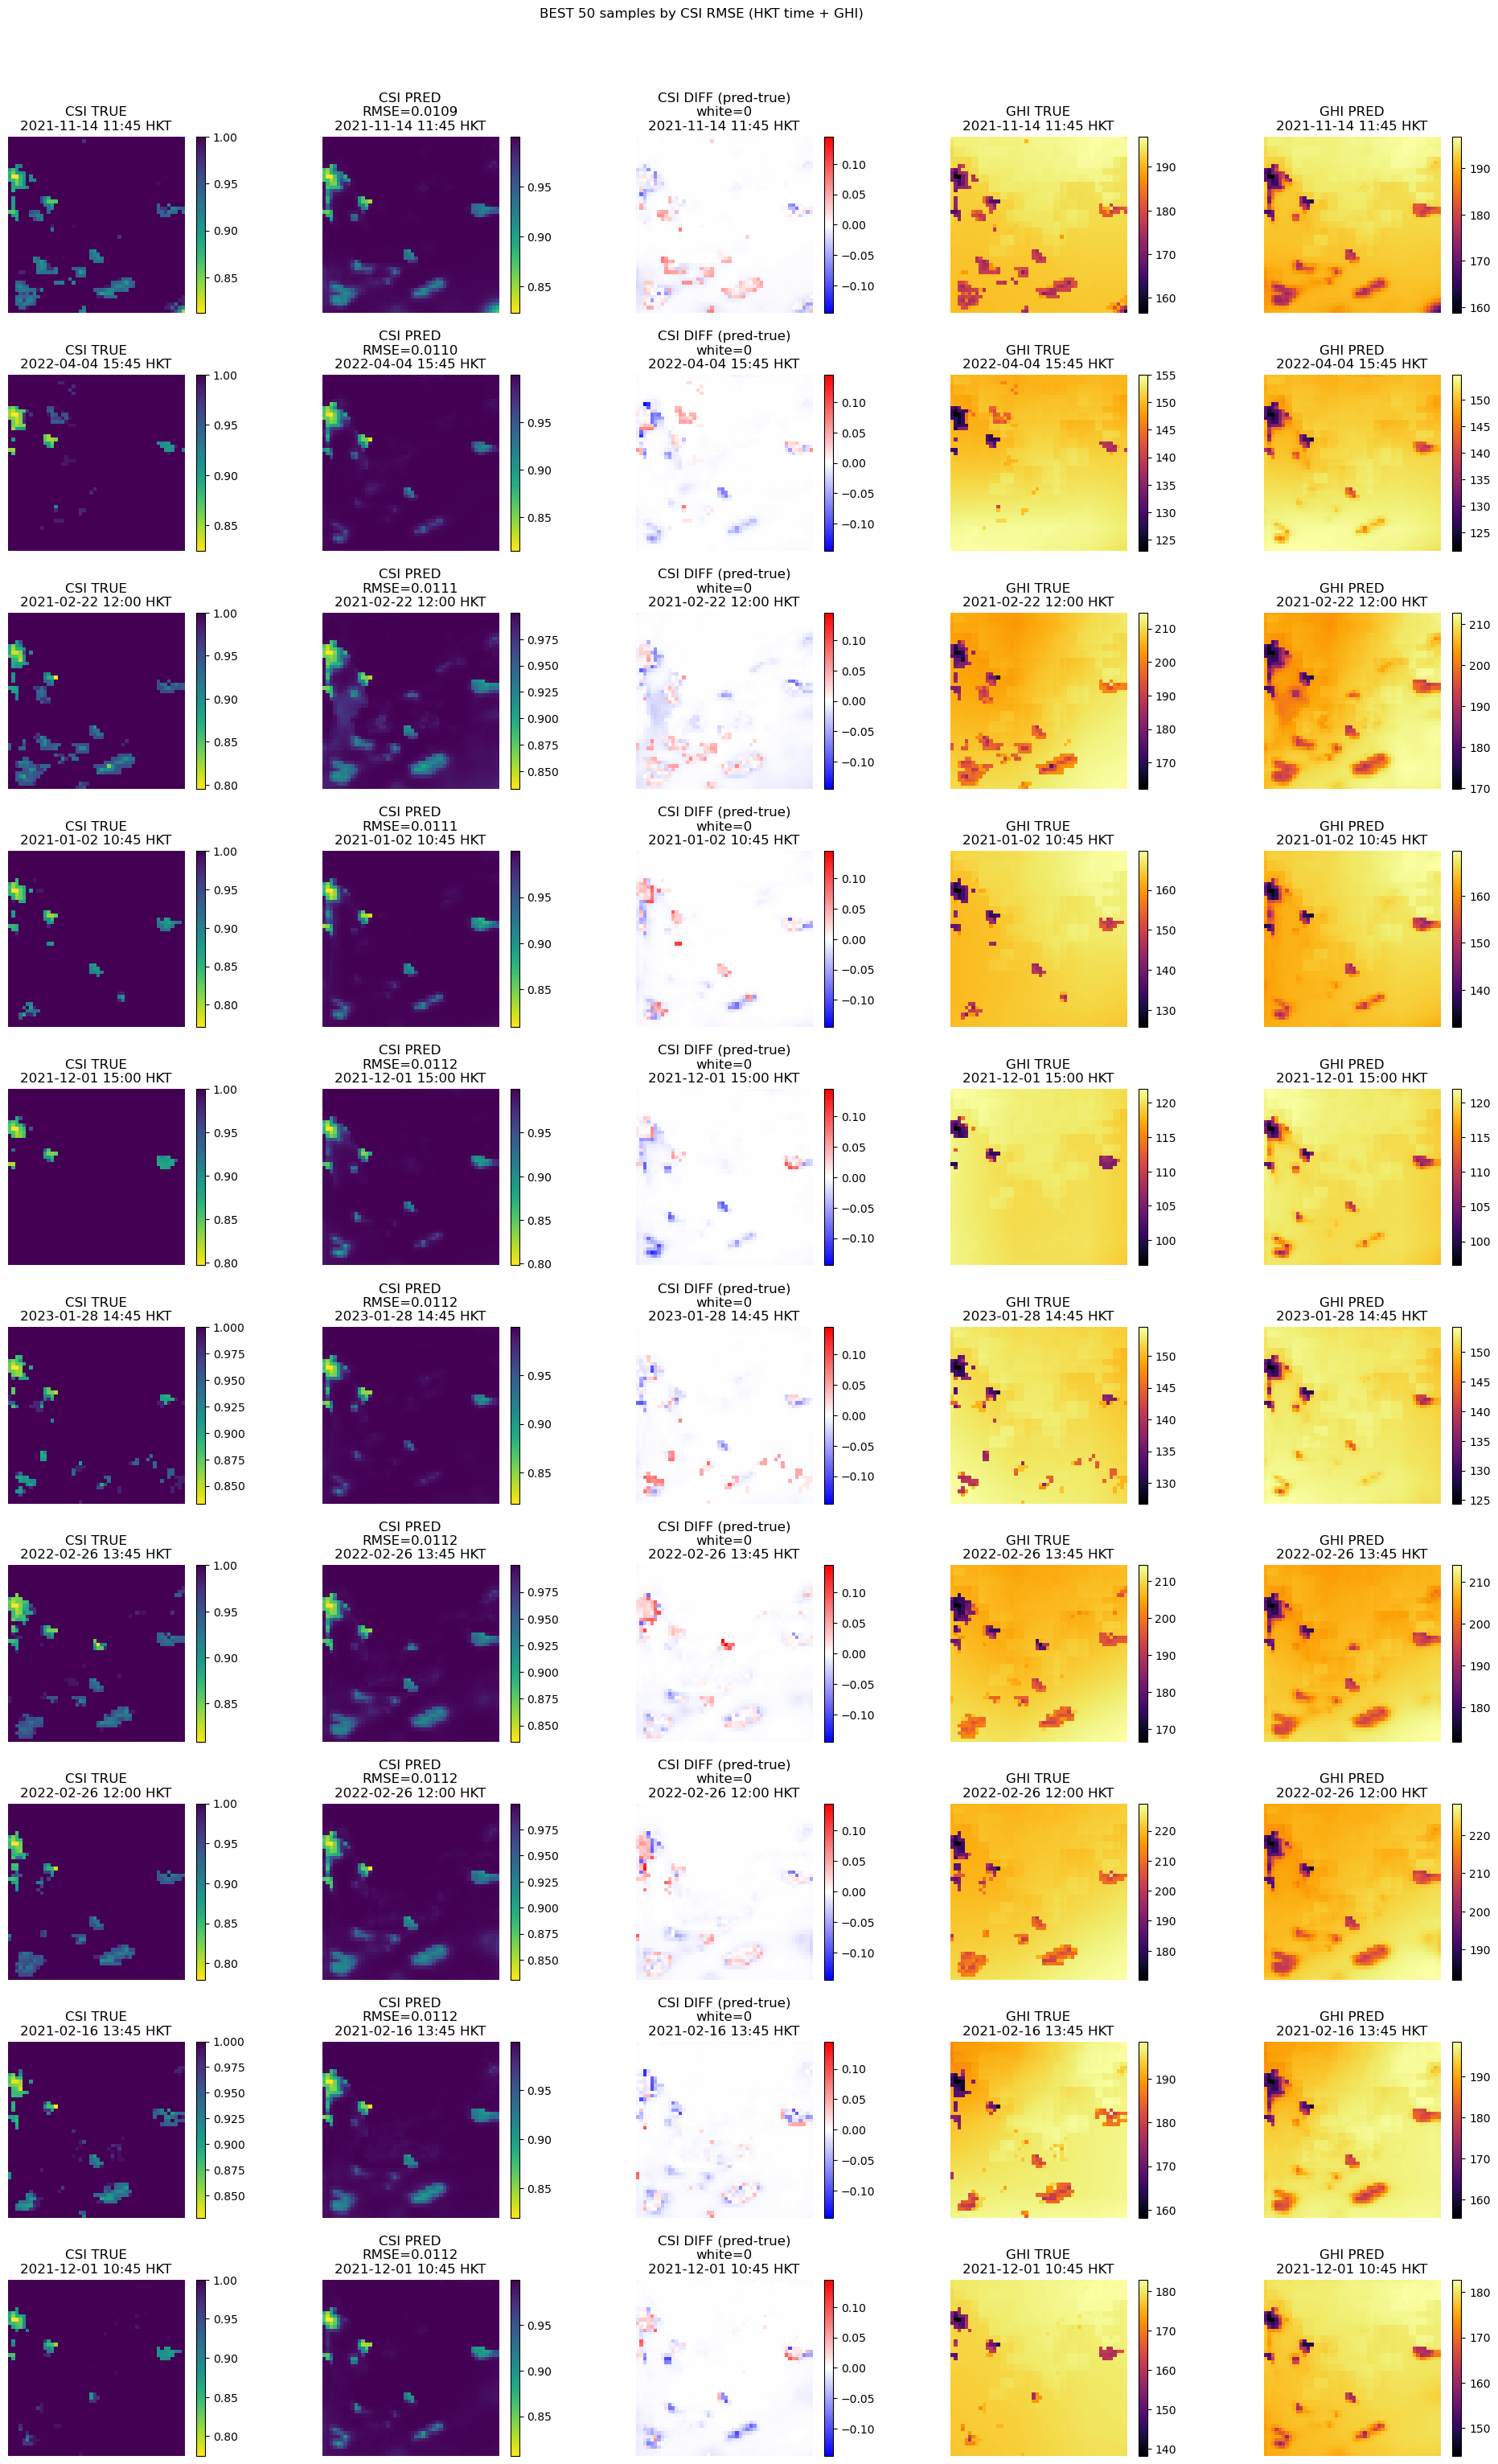

In [48]:
from src.plot import(
    plot_rmse_extremes_with_time_and_ghi
)
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="best",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)


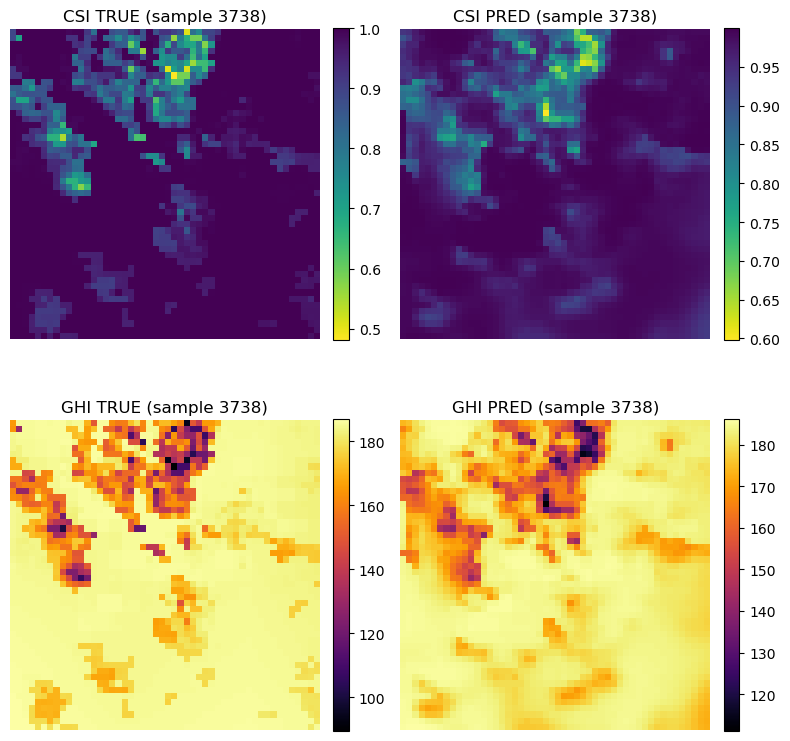

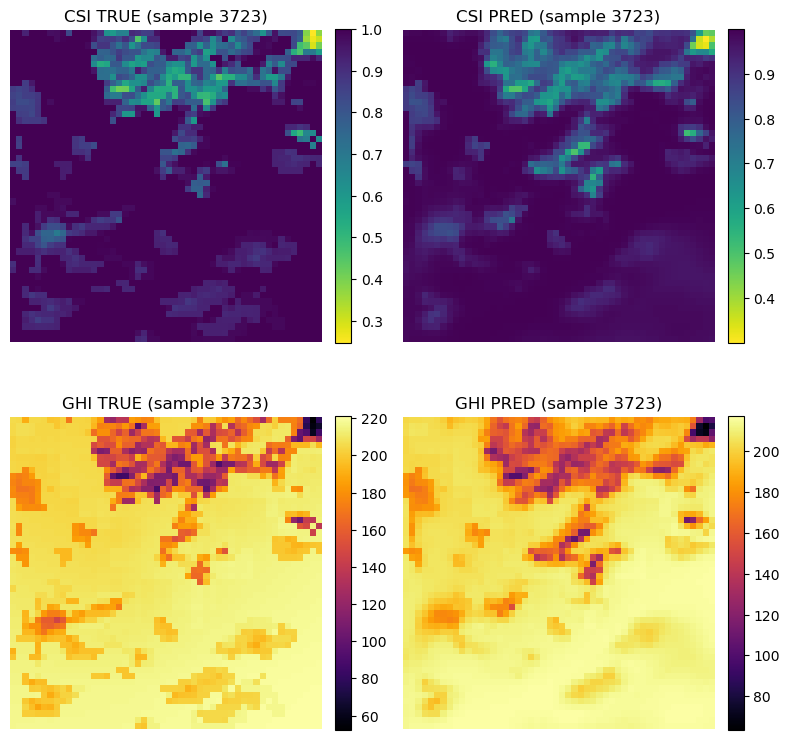

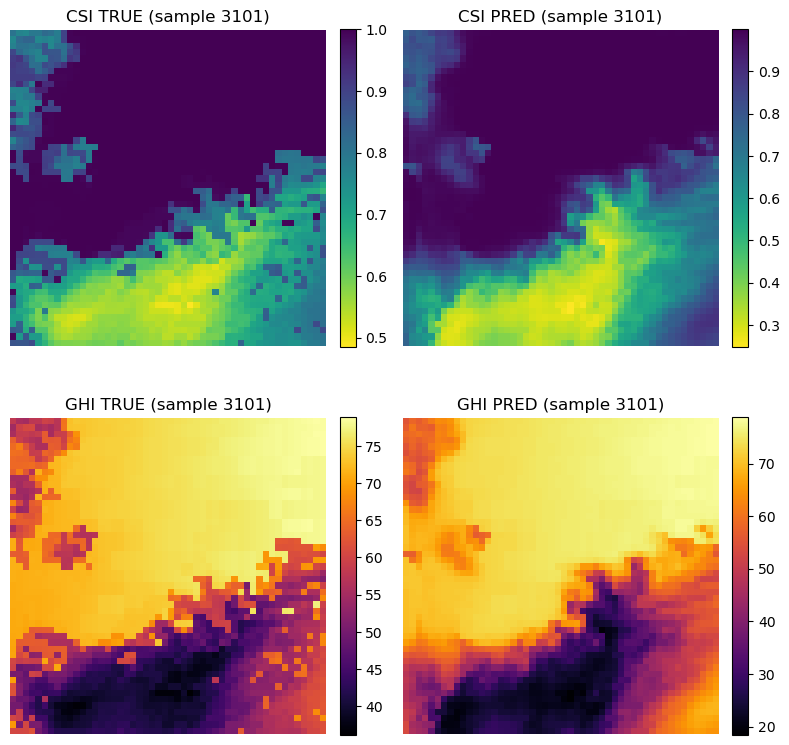

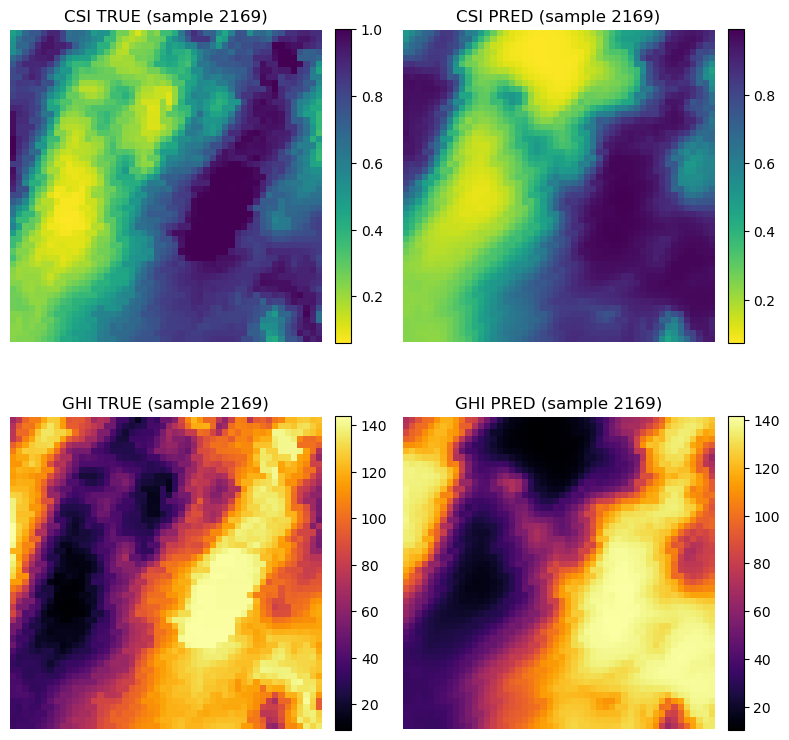

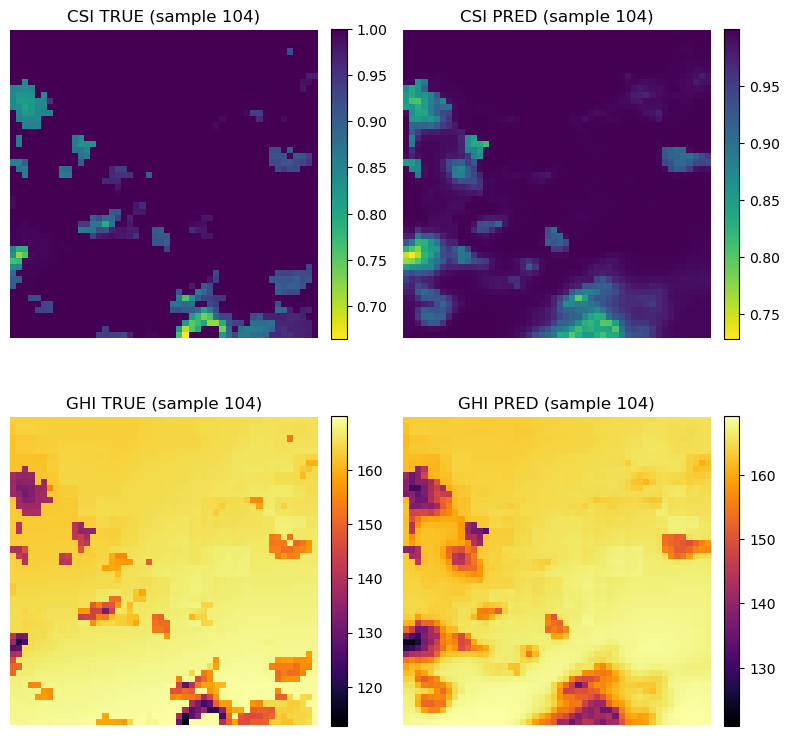

In [50]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=5,
    seed=5
)